# Práctica 4. Análisis Exploratorio de Datos: DonorsChoose
## Un recorrido visual y analítico por DonorsChoose
### Estudiante: Al Farias Leyva — Matrícula: 230389

Este notebook desarrolla el análisis exploratorio de datos del conjunto **DonorsChoose**.  
La estructura sigue la guía de referencia solicitada y cubre los apartados del **1 al 9.3**.

> Fuente de datos: archivos CSV del dataset DonorsChoose incluidos localmente en la carpeta `datasets/`.


## Contenido
1. Preparación del dataset  
2. Exploración de los donadores  
3. Exploración de las donaciones  
4. Exploración de los maestros  
5. Exploración de las escuelas  
6. Exploración de los recursos  
7. Exploración de los proyectos  
8. Procesamiento de lenguaje natural para el perfilamiento de proyectos  
9. Comprensión y comparación de características clave de los proyectos — hasta 9.3


In [1]:
# 1. Dataset Preparation
# Librerías y carga de los archivos CSV

from pathlib import Path
from io import StringIO
from datetime import date
import warnings, random, operator, string, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from plotly import tools
from wordcloud import WordCloud
import folium
from folium import plugins

warnings.filterwarnings("ignore")
init_notebook_mode(connected=True)

# El notebook busca los archivos dentro de ./datasets/
path = Path("./datasets")
if not path.exists():
    path = Path(".")

def cargar_csv(nombre, **kwargs):
    archivo = path / nombre
    if not archivo.exists():
        raise FileNotFoundError(
            f"No se encontró {archivo}. Coloca {nombre} dentro de la carpeta datasets/"
        )
    return pd.read_csv(archivo, **kwargs)

donors_df = cargar_csv("Donors.csv")
donations_df = cargar_csv("Donations.csv")
teachers_df = cargar_csv("Teachers.csv")
schools_df = cargar_csv("Schools.csv", on_bad_lines="skip")
resources_df = cargar_csv("Resources.csv")
projects_df = cargar_csv("Projects.csv")

# Se usa en los mapas por ciudad. Debe estar en datasets/ junto con los demás CSV.
zip_df = cargar_csv("zip_codes_states.csv")
print("Datasets cargados correctamente.")
display(pd.DataFrame({
    "Dataset": ["Donors", "Donations", "Teachers", "Schools", "Resources", "Projects", "Zip codes"],
    "Filas": [len(donors_df), len(donations_df), len(teachers_df), len(schools_df),
              len(resources_df), len(projects_df), len(zip_df)]
}))

Datasets cargados correctamente.


,Dataset,Filas
0,Donors,2122640
1,Donations,4687884
2,Teachers,402900
3,Schools,72993
4,Resources,7210448
5,Projects,1110017
6,Zip codes,42741


## <a id="2">2. Exploración de los donadores</a>

El dataset de donadores contiene información sobre cada donador que ha realizado al menos una donación en DonorsChoose, como ciudad, estado, código postal y si también es maestro.

## <a id="2.1">2.1 Vista general de los donadores</a>

A continuación se muestra una vista de las primeras filas del dataset de donadores.


In [2]:
###### total rows
# donors_df.shape

###### total cities 
# len(donors_df['Donor City'].value_counts())

# more than one donation
# t = donations_df['Donor ID'].value_counts().to_frame()
# len(t[t['Donor ID']>1])

donors_df.head(3)

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,00000ce845c00cbf0686c992fc369df4,Evanston,Illinois,No,602
1,00002783bc5d108510f3f9666c8b1edd,Appomattox,other,No,245
2,00002d44003ed46b066607c5455a999a,Winton,California,Yes,953


Hay un total de **2,122,640** donadores registrados en DonorsChoose hasta abril de 2018. Estos donadores pertenecen a **15,204 ciudades diferentes** de Estados Unidos y algunos otros países. De esta gran cantidad de donadores, solo **552,941**, es decir, alrededor del **26%**, han donado más de una vez. Uno de los principales objetivos del reto de Data Science for Good es encontrar ideas o recomendaciones relevantes para motivar a los donadores a donar nuevamente. Existen aproximadamente **1,471,613** donadores que solo han realizado una donación.


In [3]:
import folium
from folium import plugins
from io import StringIO
import folium 


statesll=StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490""")

tempdf = states_df = donors_df['Donor State'].value_counts()
t1 = pd.DataFrame()
t1['Donor State'] = tempdf.index
t1['Donor Count'] = tempdf.values

# tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'sum'}).reset_index()
# t1 = tempdf.sort_values('Donation Amount', ascending=False)

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(t1, on='Donor State', how='inner')
sdf 

map4 = folium.Map(location=[39.50, -98.35], tiles='CartoDB dark_matter', zoom_start=3.5)
for j, rown in sdf.iterrows():
    rown = list(rown)
    folium.CircleMarker([float(rown[1]), float(rown[2])], popup="<b>State:</b>" + rown[0].title() +"<br> <b>Donors:</b> "+str(int(rown[3])), radius=float(rown[3])*0.0001, color='#be0eef', fill=True).add_to(map4)
map4

In [4]:
def bar_hor(df, col, title, color, w=None, h=None, lm=0, limit=100, return_trace=False, rev=False):
    cnt_srs = df[col].value_counts()
    yy = cnt_srs.head(limit).index[::-1] 
    xx = cnt_srs.head(limit).values[::-1] 
    if rev:
        yy = cnt_srs.tail(limit).index[::-1] 
        xx = cnt_srs.tail(limit).values[::-1] 
        
    
    trace = go.Bar(y=yy, x=xx, orientation = 'h', marker=dict(color=color))
    if return_trace:
        return trace 
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

def bar_hor_noagg(x, y, title, color, w=None, h=None, lm=0, limit=100, rt=False):
    trace = go.Bar(y=x, x=y, orientation = 'h', marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)


def bar_ver_noagg(x, y, title, color, w=None, h=None, lm=0, rt = False):
    trace = go.Bar(y=y, x=x, marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

    
trace1 = bar_hor(donors_df, 'Donor City', "Top Cities with maximum Donors", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
trace2 = bar_hor(donors_df, 'Donor State', "Top States with maximum Donors", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
trace4 = bar_hor(donors_df, 'Donor State', "Top States with maximum Donors", '#c2d2ed', 600, 400, 200, limit = 10, return_trace=True, rev=True)


fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['States with maximum Donors','States with minimum Donors'])
# fig = tools.make_subplots(rows=2, cols=2, specs=[[{}, {}], [{'colspan': 2}, None]], print_grid=False, subplot_titles = ['States with maximum Donors','States with minimum Donors', 'Cities with maximum Donors'])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace4, 1, 2);
# fig.append_trace(trace1, 2, 1);

fig['layout'].update(height=400, showlegend=False);
iplot(fig); 

> - California, al ser el estado con mayor población, también cuenta con una gran base de donadores registrados, con cerca de 300,000 donadores. **San Francisco y Los Ángeles** son las principales ciudades de California donde se ubica la mayor cantidad de donadores. También en California se encuentra una de las mayores cantidades de escuelas y proyectos.
> - Nueva York, Texas y Florida, con aproximadamente 137,000, 134,000 y 108,000 donadores respectivamente, son otros tres estados con una alta población de donadores. Las ciudades principales incluyen Nueva York, Houston, Austin, Dallas, Miami, Tampa y Orlando.


In [5]:
census_2013 = {'Mississippi': 2991207, 'Iowa': 3090416, 'Oklahoma': 3850568, 'Delaware': 925749, 'Minnesota': 5420380, 'Alaska': 735132, 'Illinois': 12882135, 'Arkansas': 2959373, 'New Mexico': 2085287, 'Indiana': 6570902, 'Maryland': 5928814, 'Louisiana': 4625470, 'Texas': 26448193, 'Wyoming': 582658, 'Arizona': 6626624, 'Wisconsin': 5742713, 'Michigan': 9895622, 'Kansas': 2893957, 'Utah': 2900872, 'Virginia': 8260405, 'Oregon': 3930065, 'Connecticut': 3596080, 'New York': 19651127, 'California': 38332521, 'Massachusetts': 6692824, 'West Virginia': 1854304, 'South Carolina': 4774839, 'New Hampshire': 1323459, 'Vermont': 626630, 'Georgia': 9992167, 'North Dakota': 723393, 'Pennsylvania': 12773801, 'Florida': 19552860, 'Hawaii': 1404054, 'Kentucky': 4395295, 'Rhode Island': 1051511, 'Nebraska': 1868516, 'Missouri': 6044171, 'Ohio': 11570808, 'Alabama': 4833722, 'South Dakota': 844877, 'Colorado': 5268367, 'Idaho': 1612136, 'New Jersey': 8899339, 'Washington': 6971406, 'North Carolina': 9848060, 'Tennessee': 6495978, 'Montana': 1015165, 'District of Columbia': 646449, 'Nevada': 2790136, 'Maine': 1328302}

donors_from_states = dict(donors_df['Donor State'].value_counts())

don_pop = {}
for state, don in donors_from_states.items():
    if state not in census_2013:
        continue
    don_pop[state]  = float(don)*100000/ census_2013[state]

import operator
don_pop = sorted(don_pop.items(), key=operator.itemgetter(1), reverse = True)
xx = [x[0] for x in (don_pop)][1:]
yy = [x[1] for x in (don_pop)][1:]

trace2 = go.Bar(
    x=xx,
    y=yy,
    name='Donors to Population',
    marker=dict(color='green'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'States with highest Donors to Population Ratio',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

> - Se genera una gráfica interesante, ya que los estados **South Carolina** con población de 4,774,839, **Massachusetts** con población de 6,692,824 y **Connecticut** con población de 3,596,080 tienen la mayor proporción de donadores respecto a la población, así como el mayor número de donadores por cada 100,000 habitantes. South Carolina tiene 985 donadores por cada 100 mil personas, Massachusetts 907 y Connecticut 878.
> - Wyoming, Nebraska y New Mexico tienen el menor número de donadores por cada 100 mil habitantes.


In [6]:
calcit = StringIO(u"""Name,Latitude,Longitude,Total Donors,Color,Size
Los Angeles,34.052233,-118.243686,"17,922.000000",#0061ff,10
San Francisco,37.774931,-122.419417,"16,553.000000",#0061ff,10
San Diego,32.715328,-117.157256,"9,072.000000",#0061ff,10
San Jose,37.339386,-121.894956,"7,674.000000",#0061ff,10
Oakland,37.804364,-122.271114,"6,783.000000",#0061ff,10
Sacramento,38.581572,-121.494400,"4,701.000000",#0061ff,10
Bakersfield,35.373292,-119.018711,"3,758.000000",#0061ff,10
Long Beach,33.768322,-118.195617,"3,120.000000",#0061ff,10
Berkeley,37.871592,-122.272747,"2,898.000000",#0061ff,10
Irvine,33.683947,-117.794694,"2,765.000000",#0061ff,10
Fremont,37.548269,-121.988572,"2,716.000000",#0061ff,10
Walnut Creek,37.910078,-122.065183,"2,255.000000",#0061ff,10
Huntington Beach,33.660297,-117.999225,"2,185.000000",#0061ff,10
Murrieta,33.553914,-117.213922,"1,982.000000",#0061ff,10
Pleasanton,37.662431,-121.874678,"1,970.000000",#0061ff,10
Torrance,33.83585,-118.340628,"1,957.000000",#0061ff,10
San Mateo,37.562992,-122.325525,"1,956.000000",#0061ff,10
Santa Monica,34.019453,-118.491192,"1,780.000000",#0061ff,10
Livermore,37.681875,-121.768008,"1,776.000000",#0061ff,10
Santa Rosa,38.440467,-122.714431,"1,752.000000",#0061ff,10
Concord,37.977978,-122.031072,"1,623.000000",#0061ff,10
Alameda,37.765206,-122.241636,"1,548.000000",#0061ff,10
Fresno,36.746842,-119.772586,"1,543.000000",#0061ff,10
San Ramon,37.779928,-121.978014,"1,533.000000",#0061ff,10
Anaheim,33.835292,-117.914503,"1,475.000000",#0061ff,10
Pasadena,34.147786,-118.144517,"1,429.000000",#0061ff,10
Glendale,34.142508,-118.255075,"1,427.000000",#0061ff,10
Riverside,33.95335,-117.396156,"1,425.000000",#0061ff,10
Sunnyvale,37.368831,-122.036350,"1,406.000000",#0061ff,10
Chula Vista,32.640053,-117.084197,"1,398.000000",#0061ff,10
Mountain View,37.386053,-122.083850,"1,398.000000",#0061ff,10
Elk Grove,38.4088,-121.371617,"1,397.000000",#0061ff,10
Santa Clarita,34.391664,-118.542586,"1,382.000000",#0061ff,10
Burbank,34.180839,-118.308967,"1,357.000000",#0061ff,10
Redwood City,37.485214,-122.236356,"1,323.000000",#0061ff,10
Chico,39.728494,-121.837478,"1,322.000000",#0061ff,10
Whittier,33.979178,-118.032844,"1,280.000000",#0061ff,10
Corona,33.875294,-117.566439,"1,239.000000",#0061ff,10
Santa Clara,37.354108,-121.955236,"1,233.000000",#0061ff,10
Orange,33.787794,-117.853111,"1,229.000000",#0061ff,10
Palo Alto,37.441883,-122.143019,"1,219.000000",#0061ff,10
Hayward,37.668819,-122.080797,"1,162.000000",#0061ff,10
Oceanside,33.195869,-117.379483,"1,157.000000",#0061ff,10
Fullerton,33.870292,-117.925339,"1,151.000000",#0061ff,10
San Rafael,37.973536,-122.531086,"1,136.000000",#0061ff,10
Folsom,38.677958,-121.176058,"1,125.000000",#0061ff,10
Simi Valley,34.269447,-118.781483,"1,069.000000",#0061ff,10
Escondido,33.119208,-117.086422,"1,062.000000",#0061ff,10
Santa Ana,33.745572,-117.867833,"1,054.000000",#0061ff,10
Redondo Beach,33.849183,-118.388408,"1,048.000000",#34ef6c,8
Stockton,37.957703,-121.290781,"1,041.000000",#34ef6c,8
Santa Cruz,36.974117,-122.030797,"1,029.000000",#34ef6c,8
Culver City,34.021122,-118.396467,"1,019.000000",#34ef6c,8
Salinas,36.677736,-121.655500,"1,017.000000",#34ef6c,8
Martinez,38.019367,-122.134133,975.000000,#34ef6c,8
Santa Barbara,34.420831,-119.698189,936.000000,#34ef6c,8
San Leandro,37.724931,-122.156078,929.000000,#34ef6c,8
Ventura,34.274639,-119.229006,922.000000,#34ef6c,8
Roseville,38.752122,-121.288006,888.000000,#34ef6c,8
Yorba Linda,33.888625,-117.813111,888.000000,#34ef6c,8
Costa Mesa,33.641133,-117.918669,887.000000,#34ef6c,8
San Marcos,33.143372,-117.166144,866.000000,#34ef6c,8
Brentwood,34.057361,-118.480511,853.000000,#34ef6c,8
South San Francisco,37.654656,-122.407750,841.000000,#34ef6c,8
Modesto,37.639097,-120.996878,837.000000,#34ef6c,8
Temecula,33.493639,-117.148364,837.000000,#34ef6c,8
Novato,38.107419,-122.569703,831.000000,#34ef6c,8
Carlsbad,33.158092,-117.350594,822.000000,#34ef6c,8
Mission Viejo,33.600022,-117.671994,817.000000,#34ef6c,8
Brea,33.916681,-117.900061,802.000000,#34ef6c,8
Garden Grove,33.773906,-117.941447,792.000000,#34ef6c,8
Dublin,37.702153,-121.935792,784.000000,#34ef6c,8
El Cajon,32.794772,-116.962528,783.000000,#34ef6c,8
Menlo Park,37.453828,-122.182186,768.000000,#34ef6c,8
Fairfield,38.249358,-122.039967,751.000000,#34ef6c,8
Pleasant Hill,37.947978,-122.060797,725.000000,#34ef6c,8
Napa,38.297539,-122.286864,711.000000,#34ef6c,8
Richmond,37.935758,-122.347750,707.000000,#34ef6c,8
Los Altos,33.796331,-118.118119,703.000000,#34ef6c,8
Daly City,37.687925,-122.470208,702.000000,#34ef6c,8
West Covina,34.068622,-117.938953,688.000000,#34ef6c,8
Lafayette,37.885758,-122.118019,660.000000,#34ef6c,8
La Mesa,32.767828,-117.023083,649.000000,#34ef6c,8
Milpitas,37.428272,-121.906625,649.000000,#34ef6c,8
Carson,33.831406,-118.282017,647.000000,#34ef6c,8
Camarillo,34.216394,-119.037603,643.000000,#34ef6c,8
Petaluma,38.232417,-122.636653,629.000000,#34ef6c,8
Newport Beach,33.618911,-117.928947,626.000000,#34ef6c,8
Pacifica,37.613825,-122.486919,619.000000,#34ef6c,8
Gilroy,37.005783,-121.568275,618.000000,#34ef6c,8
Encinitas,33.036986,-117.291983,607.000000,#34ef6c,8
El Segundo,33.919181,-118.416464,595.000000,#34ef6c,8
Downey,33.940014,-118.132569,592.000000,#34ef6c,8
Rancho Palos Verdes,33.744461,-118.387017,592.000000,#34ef6c,8
San Clemente,33.426972,-117.611992,589.000000,#34ef6c,8
Vacaville,38.356578,-121.987744,584.000000,#34ef6c,8
Chino Hills,33.989819,-117.732586,583.000000,#34ef6c,8
Campbell,37.287164,-121.949958,580.000000,#34ef6c,8
Mill Valley,37.906036,-122.544975,578.000000,#34ef6c,8
El Cerrito,37.916133,-122.310764,576.000000,#f2ae93,6
Emeryville,37.831317,-122.285247,572.000000,#f2ae93,6
Thousand Oaks,34.107231,-118.057847,572.000000,#f2ae93,6
Burlingame,37.584103,-122.366083,570.000000,#f2ae93,6
Antioch,38.004922,-121.805789,568.000000,#f2ae93,6
Beverly Hills,34.073619,-118.400356,568.000000,#f2ae93,6
Lakewood,33.853628,-118.133956,560.000000,#f2ae93,6
Manhattan Beach,33.884736,-118.410908,557.000000,#f2ae93,6
Lancaster,34.686786,-118.154164,551.000000,#f2ae93,6
Oxnard,34.197506,-119.177053,539.000000,#f2ae93,6
San Carlos,37.507158,-122.260522,527.000000,#f2ae93,6
Rocklin,38.790733,-121.235783,526.000000,#f2ae93,6
Placentia,33.872236,-117.870336,520.000000,#f2ae93,6
Cupertino,37.322997,-122.032183,516.000000,#f2ae93,6
Tustin,33.74585,-117.826167,508.000000,#f2ae93,6
Hermosa Beach,33.862236,-118.399519,507.000000,#f2ae93,6
Rancho Cordova,38.589072,-121.302728,501.000000,#f2ae93,6
Fountain Valley,33.709186,-117.953669,498.000000,#f2ae93,6
Cypress,37.320531,-121.962242,497.000000,#f2ae93,6
Union City,37.593392,-122.043831,494.000000,#f2ae93,6
Morgan Hill,37.1305,-121.654389,488.000000,#f2ae93,6
Vallejo,38.104086,-122.256636,485.000000,#f2ae93,6
Alhambra,34.095286,-118.127014,474.000000,#f2ae93,6
Lake Forest,33.646967,-117.689217,465.000000,#f2ae93,6
Rancho Cucamonga,34.1064,-117.593108,463.000000,#f2ae93,6
Vista,33.200036,-117.242536,463.000000,#f2ae93,6
Fontana,34.092233,-117.435047,459.000000,#f2ae93,6
Moreno Valley,33.942467,-117.229672,455.000000,#f2ae93,6
Hawthorne,33.916403,-118.352575,450.000000,#f2ae93,6
Covina,34.090008,-117.890339,443.000000,#f2ae93,6
San Luis Obispo,35.282753,-120.659617,434.000000,#f2ae93,6
Newark,37.529658,-122.040239,433.000000,#f2ae93,6
Inglewood,33.961681,-118.353131,432.000000,#f2ae93,6
Oakley,37.997422,-121.712453,430.000000,#f2ae93,6
Tracy,37.73965,-121.425222,428.000000,#f2ae93,6
Redding,40.586539,-122.391675,424.000000,#f2ae93,6
Glendora,34.136119,-117.865339,423.000000,#f2ae93,6
San Bruno,37.630489,-122.411083,423.000000,#f2ae93,6
Davis,38.544906,-121.740517,417.000000,#f2ae93,6
Westminster,33.751342,-117.993992,413.000000,#f2ae93,6
Pittsburg,38.027975,-121.884681,412.000000,#f2ae93,6
Palmdale,34.579433,-118.116461,408.000000,#f2ae93,6
Visalia,36.330228,-119.292058,406.000000,#f2ae93,6
Poway,32.962822,-117.035864,403.000000,#f2ae93,6
Santa Maria,34.953033,-120.435719,403.000000,#f2ae93,6
Upland,34.097511,-117.648389,396.000000,#f2ae93,6
Laguna Niguel,33.522525,-117.707553,393.000000,#f2ae93,6
La Mirada,33.917236,-118.012008,392.000000,#f2ae93,6
South Pasadena,34.116119,-118.150350,391.000000,#f2ae93,6
Cerritos,33.858347,-118.064786,383.000000,#f2ae93,6
Lodi,38.134147,-121.272219,380.000000,#f2ae93,6
Ontario,34.063344,-117.650889,380.000000,#bab7b6,4
Lincoln,38.891564,-121.293008,376.000000,#bab7b6,4
Buena Park,33.867514,-117.998117,375.000000,#bab7b6,4
Rancho Santa Margarita,33.640856,-117.603103,373.000000,#bab7b6,4
Santee,32.838383,-116.973917,373.000000,#bab7b6,4
Sonoma,38.291858,-122.458036,372.000000,#bab7b6,4
Monrovia,34.144428,-118.001947,371.000000,#bab7b6,4
Albany,37.886869,-122.297747,368.000000,#bab7b6,4
La Habra,33.931958,-117.946172,366.000000,#bab7b6,4
San Pablo,37.962147,-122.345525,366.000000,#bab7b6,4
Belmont,37.520214,-122.275800,364.000000,#bab7b6,4
Pomona,34.055228,-117.752306,364.000000,#bab7b6,4
Gardena,33.88835,-118.308961,363.000000,#bab7b6,4
Arcadia,34.139728,-118.035344,361.000000,#bab7b6,4
Clovis,36.825228,-119.702919,360.000000,#bab7b6,4
Orinda,37.877147,-122.179689,358.000000,#bab7b6,4
Manteca,37.797428,-121.216053,357.000000,#bab7b6,4
Citrus Heights,38.707125,-121.281061,355.000000,#bab7b6,4
Redlands,34.055569,-117.182539,353.000000,#bab7b6,4
Aliso Viejo,33.575,-117.725556,345.000000,#bab7b6,4
Eureka,40.802072,-124.163672,338.000000,#bab7b6,4
West Hollywood,34.090008,-118.361744,337.000000,#bab7b6,4
Auburn,38.896564,-121.076889,335.000000,#bab7b6,4
Saratoga,37.263833,-122.023014,331.000000,#bab7b6,4
Turlock,37.494658,-120.846594,327.000000,#bab7b6,4
Chino,34.012236,-117.688944,325.000000,#bab7b6,4
Diamond Bar,34.028622,-117.810336,324.000000,#bab7b6,4
South Gate,33.954736,-118.212017,319.000000,#bab7b6,4
San Bernardino,34.108344,-117.289764,318.000000,#bab7b6,4
Claremont,34.096675,-117.719778,316.000000,#bab7b6,4
Calabasas,34.138333,-118.660833,298.000000,#bab7b6,4
Los Alamitos,33.803072,-118.072564,297.000000,#bab7b6,4
Agoura Hills,34.153339,-118.761675,295.000000,#bab7b6,4
San Gabriel,34.096111,-118.105833,295.000000,#bab7b6,4
Paso Robles,35.632278,-120.664186,292.000000,#bab7b6,4
Norwalk,33.902236,-118.081733,286.000000,#bab7b6,4
Indio,33.720578,-116.215561,284.000000,#bab7b6,4
Moorpark,34.144897,-118.268742,284.000000,#bab7b6,4
Monterey,36.600239,-121.894675,275.000000,#bab7b6,4
Arroyo Grande,35.118586,-120.590725,274.000000,#bab7b6,4
San Dimas,34.106675,-117.806725,274.000000,#bab7b6,4
La Puente,34.020011,-117.949508,273.000000,#bab7b6,4
West Sacramento,38.580461,-121.530233,273.000000,#bab7b6,4
Rohnert Park,38.339636,-122.701097,269.000000,#bab7b6,4
Monterey Park,34.062511,-118.122847,266.000000,#bab7b6,4
Laguna Hills,33.599722,-117.699444,260.000000,#bab7b6,4
Watsonville,36.910231,-121.756894,259.000000,#bab7b6,4
Clayton,37.941033,-121.935792,256.000000,#bab7b6,4
Hemet,33.747519,-116.971967,256.000000,#bab7b6,4
La Verne,34.100842,-117.767836,255.000000,#bab7b6,4
Ukiah,39.150172,-123.207783,255.000000,#f477d7,2
Palm Desert,33.722244,-116.374456,251.000000,#f477d7,2
Atascadero,35.489417,-120.670725,241.000000,#f477d7,2
Menifee,33.678333,-117.166944,241.000000,#f477d7,2
Lompoc,34.63915,-120.457942,240.000000,#f477d7,2
Merced,37.302164,-120.482967,240.000000,#f477d7,2
Sebastopol,38.402136,-122.823881,237.000000,#f477d7,2
Lake Elsinore,33.668078,-117.327261,236.000000,#f477d7,2
Millbrae,37.598547,-122.387194,234.000000,#f477d7,2
Yuba City,39.140447,-121.616911,231.000000,#f477d7,2
Woodland,38.678517,-121.773297,228.000000,#f477d7,2
Bellflower,33.881683,-118.117011,227.000000,#f477d7,2
Grass Valley,39.219061,-121.061061,227.000000,#f477d7,2
Seal Beach,33.741406,-118.104786,227.000000,#f477d7,2
Walnut,34.020289,-117.865339,227.000000,#f477d7,2
Montebello,34.016506,-118.113753,225.000000,#f477d7,2
Yucaipa,34.033625,-117.043086,225.000000,#f477d7,2
Hanford,36.32745,-119.645683,224.000000,#f477d7,2
Goleta,34.435828,-119.827639,221.000000,#f477d7,2
Hesperia,34.426389,-117.300878,221.000000,#f477d7,2
Laguna Beach,33.542247,-117.783111,221.000000,#f477d7,2
Ridgecrest,35.622456,-117.670897,218.000000,#f477d7,2
Galt,38.254636,-121.299947,217.000000,#f477d7,2
Victorville,34.536108,-117.291158,217.000000,#f477d7,2
San Juan Capistrano,33.501692,-117.662550,209.000000,#f477d7,2
Atwater,37.347717,-120.609083,208.000000,#f477d7,2
Palm Springs,33.830297,-116.545292,208.000000,#f477d7,2
Azusa,34.133619,-117.907564,203.000000,#f477d7,2
Hercules,38.017144,-122.288581,202.000000,#f477d7,2
Sonora,37.984092,-120.382139,199.000000,#f477d7,2
Beaumont,33.929461,-116.977247,198.000000,#f477d7,2
Half Moon Bay,37.463553,-122.428586,197.000000,#f477d7,2
Hollister,36.852453,-121.401603,196.000000,#f477d7,2
Westlake Village,34.145839,-118.805647,194.000000,#f477d7,2
Pico Rivera,33.983069,-118.096736,190.000000,#f477d7,2
Pinole,38.004367,-122.298858,186.000000,#f477d7,2
Compton,33.89585,-118.220072,185.000000,#f477d7,2
Sausalito,37.859094,-122.485250,183.000000,#f477d7,2
La Quinta,33.646692,-116.310008,181.000000,#f477d7,2
Dana Point,33.466972,-117.698108,175.000000,#f477d7,2
Rialto,34.1064,-117.370325,172.000000,#f477d7,2
Perris,33.782519,-117.228647,171.000000,#f477d7,2
Arcata,40.866517,-124.082839,168.000000,#f477d7,2
Pacific Grove,36.617736,-121.916622,168.000000,#f477d7,2
Lomita,33.792239,-118.315072,167.000000,#f477d7,2
San Fernando,34.281947,-118.438972,165.000000,#f477d7,2
South Lake Tahoe,38.939925,-119.977186,163.000000,#f477d7,2
El Monte,34.068622,-118.027567,158.000000,#f477d7,2
Scotts Valley,37.051061,-122.014683,158.000000,#f477d7,2
Tehachapi,35.132189,-118.448975,157.000000,#f477d7,2
Baldwin Park,34.085286,-117.960897,156.000000,#f477d7,2
Marina,36.684403,-121.802172,155.000000,#f477d7,2
Rosemead,34.080564,-118.072847,155.000000,#f477d7,2
Placerville,38.729625,-120.798547,151.000000,#f477d7,2
Highland,34.128344,-117.208650,148.000000,#f477d7,2
Lawndale,33.887236,-118.352575,143.000000,#f477d7,2
Oroville,39.513775,-121.556358,142.000000,#f477d7,2
Seaside,33.819361,-118.366647,142.000000,#f477d7,2
Wildomar,33.598914,-117.280036,142.000000,#f477d7,2
Duarte,34.13945,-117.977286,141.000000,#f477d7,2
Huntington Park,33.981681,-118.225072,141.000000,#f477d7,2
Larkspur,37.934092,-122.535253,139.000000,#f477d7,2
Del Mar,32.959489,-117.265314,138.000000,#f477d7,2
Winters,38.524906,-121.970803,138.000000,#f477d7,2
Red Bluff,40.178489,-122.235831,137.000000,#f477d7,2
Cathedral City,33.779742,-116.465292,136.000000,#f9e84a,1
Ojai,34.44805,-119.242889,136.000000,#f9e84a,1
Coronado,32.685886,-117.183089,134.000000,#f9e84a,1
Lynwood,33.930292,-118.211461,134.000000,#f9e84a,1
Temple City,34.107231,-118.057847,132.000000,#f9e84a,1
Bell,33.977514,-118.187017,124.000000,#f9e84a,1
Sierra Madre,34.161672,-118.052847,119.000000,#f9e84a,1
Nevada City,39.261561,-121.016058,118.000000,#f9e84a,1
National City,32.678108,-117.099197,117.000000,#f9e84a,1
Ceres,37.594933,-120.957711,116.000000,#f9e84a,1
Solana Beach,32.991156,-117.271147,115.000000,#f9e84a,1
La Palma,33.846403,-118.046731,114.000000,#f9e84a,1
Healdsburg,38.610467,-122.869161,110.000000,#f9e84a,1
Ripon,37.739453,-121.135414,109.000000,#f9e84a,1
Crescent City,41.755947,-124.201747,108.000000,#f9e84a,1
Malibu,34.005008,-118.810172,108.000000,#f9e84a,1
Patterson,37.4716,-121.129656,107.000000,#f9e84a,1
Maywood,33.986681,-118.185350,105.000000,#f9e84a,1
Suisun City,38.238247,-122.040244,105.000000,#f9e84a,1
Dixon,38.445464,-121.823297,104.000000,#f9e84a,1
Fort Bragg,39.445722,-123.805292,103.000000,#f9e84a,1
Oakdale,37.766594,-120.847153,103.000000,#f9e84a,1
American Canyon,38.174917,-122.260803,100.000000,#f9e84a,1
Lemon Grove,32.742553,-117.031417,97.000000,#f9e84a,1
Carpinteria,34.398883,-119.518456,96.000000,#f9e84a,1
Lemoore,36.300783,-119.782911,96.000000,#f9e84a,1
San Jacinto,33.783908,-116.958636,95.000000,#f9e84a,1
San Marino,34.121397,-118.106458,95.000000,#f9e84a,1
Paramount,33.889461,-118.159792,94.000000,#f9e84a,1
Tulare,36.207728,-119.347339,93.000000,#f9e84a,1
Twentynine Palms,34.135558,-116.054169,92.000000,#f9e84a,1
Shafter,35.500514,-119.271775,91.000000,#f9e84a,1
Norco,33.931125,-117.548661,89.000000,#f9e84a,1
Capitola,36.975228,-121.953292,88.000000,#f9e84a,1
Rio Vista,38.15575,-121.691344,88.000000,#f9e84a,1
Colton,34.073903,-117.313656,86.000000,#f9e84a,1
Brisbane,37.680767,-122.399972,85.000000,#f9e84a,1
Taft,35.142467,-119.456508,85.000000,#f9e84a,1
Imperial Beach,32.583944,-117.113086,84.000000,#f9e84a,1
Kingsburg,36.513839,-119.554017,84.000000,#f9e84a,1
Morro Bay,35.365808,-120.849900,83.000000,#f9e84a,1
Santa Fe Springs,33.947236,-118.085344,83.000000,#f9e84a,1
Rancho Mirage,33.739744,-116.412789,78.000000,#f9e84a,1
Stanton,33.802517,-117.993117,78.000000,#f9e84a,1
Madera,36.961336,-120.060717,77.000000,#f9e84a,1
Los Banos,37.058278,-120.849914,76.000000,#f9e84a,1
Riverbank,37.736039,-120.935489,76.000000,#f9e84a,1
Gridley,39.363778,-121.693583,75.000000,#f9e84a,1
Pismo Beach,35.142753,-120.641283,74.000000,#f9e84a,1
Santa Paula,34.354167,-119.059269,74.000000,#f9e84a,1
Cotati,38.327778,-122.709167,73.000000,#f9e84a,1
Port Hueneme,34.180728,-119.208158,73.000000,#f9e84a,1
Selma,36.570783,-119.612075,73.000000,#f9e84a,1
Banning,33.925572,-116.876411,71.000000,#f9e84a,1
King City,36.212744,-121.126028,71.000000,#f9e84a,1
El Centro,32.792,-115.563050,69.000000,#f9e84a,1
Lakeport,39.04295,-122.915828,69.000000,#f9e84a,1
Willits,39.409608,-123.355567,68.000000,#f9e84a,1
Barstow,34.895797,-117.017283,67.000000,#f9e84a,1
Marysville,39.145725,-121.591356,67.000000,#f9e84a,1
Orland,39.747381,-122.196375,66.000000,#f9e84a,1
Grand Terrace,34.033903,-117.313653,63.000000,#f9e84a,1
Montclair,34.077511,-117.689778,63.000000,#f9e84a,1
Villa Park,33.814461,-117.813111,63.000000,#f9e84a,1
Artesia,33.865847,-118.083122,62.000000,#f9e84a,1
Desert Hot Springs,33.961125,-116.501678,61.000000,#f9e84a,1
Fortuna,40.598186,-124.157275,61.000000,#f9e84a,1
Grover Beach,35.121642,-120.621283,61.000000,#f9e84a,1
Loma Linda,34.048347,-117.261153,59.000000,#f9e84a,1
Dinuba,36.543283,-119.387067,58.000000,#f9e84a,1
South El Monte,34.051956,-118.046733,58.000000,#f9e84a,1
Porterville,36.065231,-119.016767,57.000000,#f9e84a,1
Lathrop,37.822706,-121.276611,56.000000,#f9e84a,1
Coalinga,36.139678,-120.360150,55.000000,#f9e84a,1
Fillmore,34.399164,-118.918153,54.000000,#f9e84a,1
Mount Shasta,41.410806,-122.194575,52.000000,#f9e84a,1
Anderson,40.448208,-122.297783,51.000000,#f9e84a,1
Cloverdale,38.805461,-123.017222,50.000000,#f9e84a,1
Exeter,36.296061,-119.142053,50.000000,#f9e84a,1
Wasco,35.594125,-119.340947,50.000000,#f9e84a,1
Reedley,36.596339,-119.450403,47.000000,#f9e84a,1
Sanger,36.708006,-119.555964,47.000000,#f9e84a,1
Adelanto,34.582769,-117.409214,45.000000,#f9e84a,1
Brawley,32.978658,-115.530267,43.000000,#f9e84a,1
Calimesa,34.003903,-117.061975,42.000000,#f9e84a,1
Hughson,37.602725,-120.866481,42.000000,#f9e84a,1
Imperial,32.847553,-115.569439,41.000000,#f9e84a,1
Soledad,32.991156,-117.271147,41.000000,#f9e84a,1
Weed,41.42265,-122.386128,40.000000,#f9e84a,1
Calexico,32.678947,-115.498883,37.000000,#f9e84a,1
Willows,39.524325,-122.193592,36.000000,#f9e84a,1
Big Bear Lake,34.243897,-116.911422,35.000000,#f9e84a,1
Delano,35.768842,-119.247053,34.000000,#f9e84a,1
Newman,37.313828,-121.020761,34.000000,#f9e84a,1
Colfax,39.100731,-120.953275,33.000000,#f9e84a,1
Escalon,37.797428,-120.996603,33.000000,#f9e84a,1
Jackson,38.348803,-120.774103,32.000000,#f9e84a,1
Bishop,37.363539,-118.395111,31.000000,#f9e84a,1
Coachella,33.6803,-116.173894,31.000000,#f9e84a,1
Holtville,32.811161,-115.380264,31.000000,#f9e84a,1
Indian Wells,33.717631,-116.340756,31.000000,#f9e84a,1
San Juan Bautista,36.845511,-121.537997,31.000000,#f9e84a,1
Arvin,35.2018,-118.833106,30.000000,#f9e84a,1
Kerman,36.723558,-120.059878,30.000000,#f9e84a,1
Colusa,39.214333,-122.009417,27.000000,#f9e84a,1
Greenfield,36.3208,-121.243814,27.000000,#f9e84a,1
Waterford,37.641319,-120.760483,26.000000,#f9e84a,1
Ferndale,40.576242,-124.263944,25.000000,#f9e84a,1
Susanville,40.416283,-120.653006,25.000000,#f9e84a,1
Buellton,34.613597,-120.192650,24.000000,#f9e84a,1
Calistoga,38.578797,-122.579706,24.000000,#f9e84a,1
Clearlake,38.958231,-122.626372,24.000000,#f9e84a,1
Shasta Lake,40.680428,-122.370842,24.000000,#f9e84a,1
Yreka,41.735419,-122.634472,23.000000,#f9e84a,1
Biggs,39.412389,-121.712750,22.000000,#f9e84a,1
Chowchilla,37.123,-120.260175,22.000000,#f9e84a,1
Live Oak,36.983561,-121.980517,22.000000,#f9e84a,1
McFarland,35.678011,-119.229275,22.000000,#f9e84a,1
Fowler,36.630506,-119.678469,21.000000,#f9e84a,1
Gonzales,36.506628,-121.444381,21.000000,#f9e84a,1
Solvang,34.595819,-120.137647,21.000000,#f9e84a,1
Angels Camp,38.067783,-120.538531,20.000000,#f9e84a,1
Gustine,37.257717,-120.998814,20.000000,#f9e84a,1
Sutter Creek,38.392967,-120.802436,20.000000,#f9e84a,1
Wheatland,39.009894,-121.423014,20.000000,#f9e84a,1
Hawaiian Gardens,33.831403,-118.072842,19.000000,#f9e84a,1
Lindsay,36.203006,-119.088161,19.000000,#f9e84a,1
Livingston,37.386883,-120.723533,19.000000,#f9e84a,1
California City,35.1258,-117.985903,18.000000,#f9e84a,1
Corning,39.927658,-122.179156,18.000000,#f9e84a,1
Trinidad,41.059292,-124.143125,18.000000,#f9e84a,1
Ione,38.352692,-120.932717,17.000000,#f9e84a,1
Dunsmuir,41.208208,-122.271953,16.000000,#f9e84a,1
Tulelake,41.955989,-121.477492,15.000000,#f9e84a,1
Firebaugh,36.858839,-120.456008,13.000000,#f9e84a,1
Woodlake,36.413561,-119.098717,13.000000,#f9e84a,1
Blue Lake,40.882908,-123.983950,12.000000,#f9e84a,1
Blythe,33.617233,-114.589175,12.000000,#f9e84a,1
Avalon,33.342819,-118.328228,11.000000,#f9e84a,1
Montague,41.728197,-122.527800,11.000000,#f9e84a,1
Williams,39.154614,-122.149419,11.000000,#f9e84a,1
Alturas,41.487114,-120.542456,10.000000,#f9e84a,1
Corcoran,37.977978,-122.031072,9.000000,#f9e84a,1
Isleton,38.161861,-121.611622,9.000000,#f9e84a,1
Piedmont,37.824372,-122.231636,9.000000,#f9e84a,1
Rio Dell,40.4993,-124.106436,9.000000,#f9e84a,1
Huron,36.202731,-120.102917,8.000000,#f9e84a,1
Point Arena,38.908797,-123.693072,8.000000,#f9e84a,1
Dorris,41.967369,-121.918061,7.000000,#f9e84a,1
Dos Palos,36.986058,-120.626572,7.000000,#f9e84a,1
Etna,41.456806,-122.894756,6.000000,#f9e84a,1
Guadalupe,34.971644,-120.571836,6.000000,#f9e84a,1
Needles,34.848061,-114.614133,6.000000,#f9e84a,1
Plymouth,38.481853,-120.844658,5.000000,#f9e84a,1
Avenal,36.004122,-120.129028,4.000000,#f9e84a,1
Fort Jones,41.663864,-124.252892,4.000000,#f9e84a,1
Portola,39.810458,-120.469103,4.000000,#f9e84a,1
Calipatria,33.125597,-115.514153,3.000000,#f9e84a,1
Farmersville,36.297728,-119.206778,3.000000,#f9e84a,1
Loyalton,39.676294,-120.241039,3.000000,#f9e84a,1
Maricopa,35.058858,-119.400950,2.000000,#f9e84a,1
Parlier,36.611617,-119.527072,2.000000,#f9e84a,1
Bell Gardens,33.965292,-118.151458,1.000000,#f9e84a,1
Orange Cove,36.624394,-119.313731,1.000000,#f9e84a,1
San Joaquin,36.606617,-120.189044,1.000000,#f9e84a,1
Westmorland,33.037267,-115.621383,1.000000,#f9e84a,1""")



cities = pd.read_csv(calcit)
cities = cities.dropna()

# map_osm = folium.Map(location=[36.611617,-119.527072], zoom_start=5)

# for i, row in cities.iterrows():
#     folium.CircleMarker([row['Latitude'], row['Longitude']],
#                         radius=row['Size'],
#                         color=row['Color'],
#                         fill_color=row['Color'],
#                        ).add_to(map_osm)



map_osm2 = folium.Map([36.611617,-119.527072], zoom_start=6,tiles='cartodbdark_matter')
ziparr = []
for i, row in cities.iterrows():
    ziparr.append([row['Latitude'],row['Longitude'], float(row['Total Donors'].replace(",",""))])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))
map_osm2


> Las ubicaciones principales donde la densidad de donadores es más alta son las siguientes:

    - Los Angeles, 17,922  
    - San Francisco, 16,553  
    - San Diego, 9,072  
    - San Jose, 7,674  
    - Oakland, 6,783

## <a id="2.4.2">2.4.2 Dónde se localizan los donadores en Florida</a>


In [7]:
c = zip_df.copy()
c = c.dropna()

fldf = c[c['state'] == 'FL'][['city', 'latitude', 'longitude']]

fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
t = donors_df[donors_df['Donor State'] == 'Florida']['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([29.813456, -82.472049], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))


> La región de tres condados de Florida: Palm Beach, Miami-Dade y Broward, tiene una alta concentración de donadores. La ciudad de Tampa también cuenta con un número importante de donadores. Algunos donadores también se encuentran en una de las zonas más costosas y del extremo sur de Estados Unidos, conocida como el área de Key West en Florida. A continuación se muestran los conteos de las principales ciudades:

> Miami (9309), Tampa (6016), Orlando (5658), Jacksonville (4598), Fort Lauderdale (4311), West Palm Beach (2400)

## <a id="2.4.3">2.4.3 Dónde se localizan los donadores en Nueva York</a>


In [8]:
fldf = c[c['state'] == 'NY'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'New York']['Donor City'].value_counts()

fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([42.315975, -74.065515], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))


> Los donadores de Nueva York se concentran principalmente en la ciudad de Nueva York. Las 5 principales ciudades son:  
- New York                26820  
- Brooklyn                21715  
- Staten Island            4516  
- Bronx                    4455  
- Buffalo                  2232  

## <a id="2.4.4">2.4.4 Dónde se localizan los donadores en Texas</a>


In [9]:
fldf = c[c['state'] == 'TX'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'Texas']['Donor City'].value_counts()

fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([31.884540, -97.077218], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))


> Las principales ciudades de Texas donde se localizan los donadores son:

- Houston             15404
- Austin               9958
- Dallas               7818
- San Antonio          6465
- Fort Worth           4350

## <a id="2.5">2.5 Dónde se localizan los donadores?</a>


In [10]:
fldf = c[['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([39.3714557,-94.3541242], zoom_start=3.5,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=10))


> Aunque la mayor cantidad de donadores proviene del estado de California, ubicado en la costa oeste, la región de la costa este de Estados Unidos presenta una alta densidad de donadores en comparación con la costa oeste. También existe una cantidad importante de donadores en Hawaii y Alaska.

## <a id="2.6">2.6 Número de donadores maestros y no maestros por estado</a>


In [11]:
# which city and state has maximum teacher donors 
tempdf = donors_df.groupby(['Donor State', 'Donor Is Teacher']).agg({'Donor Is Teacher' : 'count' }).rename(columns={'Donor Is Teacher' : 'Teacher Donor Counts'}).reset_index()

no_df = tempdf[tempdf['Donor Is Teacher']=='No']
no_x = no_df['Donor State']
no_y = no_df['Teacher Donor Counts']
yes_df = tempdf[tempdf['Donor Is Teacher']=='Yes']
yes_x = yes_df['Donor State']
yes_y = yes_df['Teacher Donor Counts']

trace1 = go.Bar(
    x=no_x,
    y=no_y,
    name='Non Teacher Donors',
    marker=dict(color='#f259d6'),
    opacity=0.8
)
trace2 = go.Bar(
    x=yes_x,
    y=yes_y,
    name='Teacher Donors',
    marker=dict(color='#f7bb31'),
    opacity=0.8
)

data = [trace1, trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'States and the distribution of Teacher and Non Teacher Donors',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

> El número de donadores que también son maestros es mucho menor en todos los estados. Los registros cuyo estado aparece como "others" tienen la mayor cantidad de donadores maestros, con aproximadamente 28,000.

## <a id="3">3. Exploración de las donaciones</a>  

El archivo de donaciones incluye información sobre las donaciones realizadas por los donadores, el monto total donado, la secuencia del carrito del donador, la fecha, el proyecto y el ID del donador.

## <a id="3.1">3.1 Vista general de las donaciones</a>


In [12]:
donations_df[['Donation ID', 'Donation Included Optional Donation', 'Donation Amount',
       'Donor Cart Sequence', 'Donation Received Date', 'Project ID', 'Donor ID']].head(3)
# donations_df.columns

# len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 20000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 10000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] < 1])
# np.mean(donations_df['Donation Amount'])

,Donation ID,Donation Included Optional Donation,Donation Amount,Donor Cart Sequence,Donation Received Date,Project ID,Donor ID
0,688729120858666221208529ee3fc18e,No,178.37,11,2016-08-23 13:15:57,000009891526c0ade7180f8423792063,1f4b5b6e68445c6c4a0509b3aca93f38
1,dcf1071da3aa3561f91ac689d1f73dee,Yes,25.00,2,2016-06-06 20:05:23,000009891526c0ade7180f8423792063,4aaab6d244bf3599682239ed5591af8a
2,18a234b9d1e538c431761d521ea7799d,Yes,20.00,3,2016-06-06 14:08:46,000009891526c0ade7180f8423792063,0b0765dc9c759adc48a07688ba25e94e


Hasta abril de 2018 se han realizado un total de **4,687,884 donaciones** en DonorsChoose. El monto más alto donado es de **USD 60,000**, realizado en 2013. Solo **6 donaciones superan los USD 20,000**, mientras que únicamente **61 pagos superan los USD 10,000**. La mayoría de los pagos, alrededor del **83%** de todas las donaciones, son **menores a USD 100**. Existen 350 pagos menores a USD 1; aunque son montos pequeños, también pueden hacer una diferencia. Hasta abril de 2018, DonorsChoose ha recaudado una cantidad total enorme de **USD 284,408,243** a través de su plataforma. El monto promedio donado en DonorsChoose es de aproximadamente USD 60. En las siguientes secciones se revisan los detalles de donadores y proyectos relacionados con estas donaciones.

## <a id="3.2">3.2 Proyectos y sus donaciones</a>

Se identifican los proyectos principales y sus atributos relacionados:

- 3.2.1 Proyectos con mayor número de donadores  
- 3.2.2 Proyectos con mayor monto total financiado  
- 3.2.3 Proyectos con mayor monto promedio por donador  
- 3.2.4 Proyectos con la donación individual más alta


In [13]:
# Which Projects Had the maximum Donations 

tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Project ID' : "Total Donations", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']

tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pa"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']
tr1 = bar_ver_noagg(x, y, 'Total Donations', '#43ef4b', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pb"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Average Donations', '#7fef84', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Project ID']
x = ["Pc"+str(i+1) for i in range(len(x))]
y = tempdf1[tempdf1['Total Donations'] > 10].head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Average Donations (Min: 10 Donations)', '#a5d1a7', lm=None, rt=True)

tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Project ID' : "Total Donations", 'Donation Amount' : "Maximum Donations"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Maximum Donations'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pd"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donations']
tr4 = bar_ver_noagg(x, y, 'Maximum Donations', '#c0d1c1', lm=None, rt=True)



fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Amount Per Donor (Min 10 Donations)', 'Maximum Single Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);
fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Top Projects and their - Total Donations, Total Amount, Amount Per Donor, Maximum Single Amount');
iplot(fig); 

> - **Proyectos principales**  
> - En la historia de DonorsChoose, distintos proyectos han recibido una cantidad variable de donaciones, desde 1 hasta más de 800 donaciones. El número máximo de donaciones realizadas a un solo proyecto es de 863. Este fue un proyecto dirigido por un maestro y su título fue "**Vallecito StandUpKids Pilot Standing School!**" como se muestra como Pa1 en la primera gráfica. El monto total financiado en este proyecto fue de **USD 108,248.30** y fue financiado completamente el 26 de agosto de 2015.
> - Existen otros tres proyectos con una cantidad muy alta de donaciones, mayor a 600.
> - En noviembre de 2016 se inició un proyecto titulado "**Varsity and After-School Fencing Teams in NYC**", mostrado como Pc1 en la segunda gráfica, con 18 donaciones en total. Este proyecto tuvo el monto promedio más alto por donador, equivalente a **USD 1,850**.
> - En el proyecto titulado "**Learning to Play While Playing to Learn!**", mostrado como Pd1 en la cuarta gráfica, se realizó la donación individual máxima de **USD 60,000**, la cual es la donación individual más alta en la historia de DonorsChoose.

## <a id="3.3">3.3 Quiénes son los principales donadores:</a>

Se identifican los donadores que realizaron algunas de las contribuciones más importantes:
- 3.3.1 Donadores que han realizado el mayor número de donaciones  
- 3.3.2 Donadores que han financiado los montos totales más altos  
- 3.3.3 Donadores que financian los montos promedio más altos en donaciones individuales  
- 3.3.4 Donadores que han realizado la donación individual máxima


In [14]:
# Which Projects Had the maximum Donations 

tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Donor ID' : "Total Donations", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Total Donations']

tempdf1 = tempdf.sort_values(by=['Total Donations'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Donations']
tr1 = bar_ver_noagg(x, y, 'Total Donations', '#d141ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Average Donations', '#db85ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Average Donations', '#d5b1db', lm=None, rt=True)

tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Donor ID' : "Total Donations", 'Donation Amount' : "Maximum Donations"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Maximum Donations'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Maximum Donations']
tr4 = bar_ver_noagg(x, y, 'Maximum Donations', '#ccbece', lm=None, rt=True)

fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Donated Amount', 'Maximum Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);
fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Top Donors and their Top Contributions');
iplot(fig); 

> - **Donadores más generosos:**  
> - Un donador que no es maestro, ubicado en **Manhattan Beach, California**, ha donado más de **18,000 veces** en DonorsChoose, mostrado como D1 en la gráfica superior izquierda. Otro donador no maestro de Nueva York ha donado una cantidad total enorme de **1.8 millones de USD** en alrededor de 10,513 donaciones, mostrado como D1 en la gráfica superior derecha.
> - El pago individual más alto de **60K** para el proyecto "Learning to Play while Playing to Learn" fue realizado por un donador de **Anahola, Hawaii**, quien ha realizado 223 donaciones en total hasta el momento.

## <a id="3.4">3.4 Qué montos de donación se recibieron y en qué momentos?</a>

### Donaciones por año
 - 3.4.1 Número de donaciones por año
 - 3.4.2 Monto promedio de donación por año


In [15]:
donations_df['Donation Date'] = pd.to_datetime(donations_df['Donation Received Date'])
donations_df['Donation Year'] = donations_df['Donation Date'].dt.year
donations_df['Donation Month'] = donations_df['Donation Date'].dt.month
donations_df['Donation Day'] = donations_df['Donation Date'].dt.day
donations_df['Donation Weekday'] = donations_df['Donation Date'].dt.weekday
donations_df['Donation Hour'] = donations_df['Donation Date'].dt.hour

t1 = donations_df.groupby(['Donation Year']).agg({'Donation Month' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Month' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t1['Donation Year']
y1 = t1['Total Donations']
y2 = t1['Average Amount']
trace1 = go.Scatter(x=x[:-1], y=y1[:-1], fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x[:-1], y=y2[:-1], fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per Year</b>", "<b>Average Donation Amount per Year</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(

    height=300,

    showlegend=False,

    yaxis=dict(

        autorange=True,

        showgrid=False,

        zeroline=False,

        showline=False,

        ticks='',

        showticklabels=False

    ),

    yaxis2=dict(

        autorange=True,

        showgrid=False,

        zeroline=False,

        showline=False,

        ticks='',

        showticklabels=False

    )

)

iplot(fig)

> Desde el año 2012, el número de donaciones en DonorsChoose ha aumentado de forma regular. Con cerca de 150 donaciones recibidas en 2012, DonorsChoose recibió aproximadamente **1.1 millones de donaciones** en 2017. El monto más alto recibido en 2017 fue de **USD 31,856**, proveniente de un donador de **Lafayette, Colorado**. Esta donación se recibió el 2 de marzo de 2017.  
> En el mismo año, se recibió una cantidad enorme de donaciones de un donador de **Manhattan Beach, California**, quien realizó **13,751 donaciones**.  
> El monto promedio de donación recibido por año se acerca a **USD 60**, mientras que fue más alto en el año inicial, 2012, con **USD 166**.

### Donaciones por mes
- 3.4.3 Número de donaciones por mes
- 3.4.4 Monto promedio de donaciones por mes


In [16]:
t2 = donations_df.groupby(['Donation Month']).agg({
    'Donation Year': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Year': 'Total Donations',
    'Donation Amount': 'Average Amount'
})

x = t2['Donation Month']
y1 = t2['Total Donations']
y2 = t2['Average Amount']

trace1 = go.Scatter(
    x=x,
    y=y1,
    fill='tozeroy',
    fillcolor='#fcc45f',
    mode='none'
)

trace2 = go.Scatter(
    x=x,
    y=y2,
    fill='tozeroy',
    fillcolor='#e993f9',
    mode='none'
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    print_grid=False,
    subplot_titles=[
        "<b>Donations per Month</b>",
        "<b>Average Donation Amount per Month</b>"
    ]
)

fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)

fig['layout'].update(
    height=300,
    showlegend=False,
    yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ),
    yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    )
)

iplot(fig)

> - La mayor cantidad de donaciones se recibió en el mes de **agosto, con 577,274 donaciones**, seguido de **septiembre, con 518,908 donaciones**. La menor cantidad de donaciones se recibió en **junio, con 191,221 donaciones**, y en **mayo, con 243,440 donaciones**, probablemente por el verano y el periodo vacacional. El monto promedio de donación más alto se recibió en diciembre, con **USD 80**, mientras que el menor fue en julio, con **USD 51**. En promedio, el monto de donación por año se acerca a USD 59.

### Donaciones por día del mes
- 3.4.5 Número de donaciones por día del mes
- 3.4.6 Monto promedio de donaciones por día del mes


In [17]:
t3 = donations_df.groupby(['Donation Day']).agg({
    'Donation Year': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Year': 'Total Donations',
    'Donation Amount': 'Average Amount'
})

x = t3['Donation Day']
y1 = t3['Total Donations']
y2 = t3['Average Amount']

trace1 = go.Scatter(
    x=x,
    y=y1,
    fill='tozeroy',
    fillcolor='#fcc45f',
    mode='none'
)

trace2 = go.Scatter(
    x=x,
    y=y2,
    fill='tozeroy',
    fillcolor='#e993f9',
    mode='none'
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    print_grid=False,
    subplot_titles=[
        "<b>Donations per MonthDay</b>",
        "<b>Average Donation Amount per MonthDay</b>"
    ]
)

fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)

fig['layout'].update(
    height=300,
    showlegend=False,
    yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ),
    yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    )
)

iplot(fig)

### Donaciones por día de la semana
- 3.4.7 Número de donaciones por día de la semana
- 3.4.8 Monto promedio de donaciones por día de la semana


In [18]:
t4 = donations_df.groupby(['Donation Weekday']).agg({'Donation Year' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Year' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t4['Donation Weekday']
y1 = t4['Total Donations']
y2 = t4['Average Amount']
trace1 = go.Scatter(x=x, y=y1, fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x, y=y2, fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per WeekDay</b>", "<b>Average Donation Amount per WeekDay</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(height=300, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ), yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ));
iplot(fig); 


> El número de donaciones es mayor al inicio de la semana, es decir, lunes, martes y miércoles, con aproximadamente 700K, 800K y 750K donaciones totales respectivamente. El conteo disminuye durante los siguientes días de la semana. La menor cantidad de donaciones se recibe los sábados, como se observa en la gráfica.

### Donaciones por hora
- 3.4.9 Número de donaciones por hora
- 3.4.10 Monto promedio de donaciones por hora


In [19]:
t5 = donations_df.groupby(['Donation Hour']).agg({'Donation Month' : 'count', 'Donation Amount' : 'mean'}).reset_index().rename(columns={'Donation Month' : 'Total Donations', 'Donation Amount' : 'Average Amount'})
x = t5['Donation Hour']
y1 = t5['Total Donations']
y2 = t5['Average Amount']
trace1 = go.Scatter(x=x[:-1], y=y1[:-1], fill='tozeroy', fillcolor = '#fcc45f', mode= 'none')
trace2 = go.Scatter(x=x[:-1], y=y2[:-1], fill='tozeroy', fillcolor = "#e993f9", mode= 'none')
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["<b>Donations per Hour</b>", "<b>Average Donation Amount per Hour</b>"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);

fig['layout'].update(height=300, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ), yaxis2=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ));
iplot(fig); 


## <a id="3.5">3.5 Donaciones opcionales y donadores maestros</a>

### <a id="3.5.1">3.5.1 Total de donaciones opcionales y sus montos promedio asociados</a>


In [20]:
tempdf = donations_df.groupby('Donation Included Optional Donation').agg({'Donation Included Optional Donation' : 'count', 'Donation Amount' : 'mean'})
values1 = list(tempdf['Donation Included Optional Donation']) 
values2 = list(tempdf['Donation Amount']) 
values2t = [str("$")+str(int(x)) for x in values2]
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

labels = list(tempdf.index)
mp={'Yes' : 'Optional Donations', 'No' : 'No Optional Donations'}
labels = [mp[x] for x in labels]
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=[  '#75e575', '#ea7c96',]))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]), textinfo = "text", text=values2t)

layout = go.Layout(title='Number of Donations with Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Average Amount Donated in Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

fig = {
  "data": [
    {
      "values": values1,
      "labels": list(reversed(labels)),
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=[  '#f9345b',  '#75e575']),
      "name": "No. of donations with Optional Donations",
#       "hoverinfo":"label+percent+name",
#       "hole": .4,
        
      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
        "marker" : dict(colors=['75e575', '#f9345b']),
      "domain": {"x": [.52, 1]},
      "name": "Average Amount Donated in Optional Donations",
        "text" : values2t,
        "textinfo" : "text",
      "type": "pie"
    }],
  "layout": {
        "title":"Optional Donations : Total Count and Average Donation Amount",
    
    }
}
iplot(fig, filename='donut')

> - Los proyectos de DonorsChoose también cuentan con la opción de donaciones opcionales. El monto promedio de una donación opcional es de **USD 58**, mientras que para una donación no opcional es de **USD 73**. Del total de donaciones realizadas, aproximadamente **15%** fueron donaciones opcionales.

### <a href="3.5.2">3.5.2 Total de donaciones de donadores maestros y sus montos promedio asociados</a>


In [21]:
# lets combine donors and donations 
combined_df = donations_df.merge(donors_df, on='Donor ID', how='inner')
# combined_df.head(10)

tempdf = combined_df.groupby('Donor Is Teacher').agg({'Donor Is Teacher' : 'count', 'Donation Amount' : 'mean'})
values1 = list(tempdf['Donor Is Teacher']) 
values2 = list(tempdf['Donation Amount']) 
values2t = [str("$")+str(int(x)) for x in values2]
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

labels = list(tempdf.index)
mp={'Yes' : 'Teacher Donor', 'No' : 'Non Teacher Donor'}
labels = [mp[x] for x in labels]
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=[  '#75e575', '#ea7c96',]))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]), textinfo = "text", text=values2t)

layout = go.Layout(title='Number of Donations with Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Average Amount Donated in Optional Donations', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

fig = {
  "data": [
    {
      "values": values1,
      "labels": labels,
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=[ '#ab97db',  '#b0b1b2']),
      "name": "No. of donations with Optional Donations",
#       "hoverinfo":"label+percent+name",
#       "hole": .4,
        
      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
        "marker" : dict(colors=[ '#ab97db',  '#b0b1b2']),
      "domain": {"x": [.52, 1]},
      "name": "Average Amount Donated in Optional Donations",
        "text" : values2t,
        "textinfo" : "text",
      "type": "pie"
    }],
  "layout": {
        "title":"Optional Donations : Total Count and Average Donation Amount",
    
    }
}
iplot(fig, filename='donut')

> - Aproximadamente **29%** del total de donaciones en DonorsChoose son realizadas por donadores que también son maestros. La mayor cantidad de estos donadores maestros se encuentra en California.
> - El monto promedio de donación de un maestro es de **USD 45**, mientras que para donadores que no son maestros es de **USD 66**.


In [22]:

def mapp(df, scl, t):
    state_to_code = {'District of Columbia' : 'dc','Mississippi': 'MS', 'Oklahoma': 'OK', 'Delaware': 'DE', 'Minnesota': 'MN', 'Illinois': 'IL', 'Arkansas': 'AR', 'New Mexico': 'NM', 'Indiana': 'IN', 'Maryland': 'MD', 'Louisiana': 'LA', 'Idaho': 'ID', 'Wyoming': 'WY', 'Tennessee': 'TN', 'Arizona': 'AZ', 'Iowa': 'IA', 'Michigan': 'MI', 'Kansas': 'KS', 'Utah': 'UT', 'Virginia': 'VA', 'Oregon': 'OR', 'Connecticut': 'CT', 'Montana': 'MT', 'California': 'CA', 'Massachusetts': 'MA', 'West Virginia': 'WV', 'South Carolina': 'SC', 'New Hampshire': 'NH', 'Wisconsin': 'WI', 'Vermont': 'VT', 'Georgia': 'GA', 'North Dakota': 'ND', 'Pennsylvania': 'PA', 'Florida': 'FL', 'Alaska': 'AK', 'Kentucky': 'KY', 'Hawaii': 'HI', 'Nebraska': 'NE', 'Missouri': 'MO', 'Ohio': 'OH', 'Alabama': 'AL', 'Rhode Island': 'RI', 'South Dakota': 'SD', 'Colorado': 'CO', 'New Jersey': 'NJ', 'Washington': 'WA', 'North Carolina': 'NC', 'New York': 'NY', 'Texas': 'TX', 'Nevada': 'NV', 'Maine': 'ME'}
    df['state_code'] = statesdf['state'].apply(lambda x : state_to_code[x] if x in state_to_code else "")

    data = [ dict(
            type='choropleth',
            colorscale = scl,
            autocolorscale = False,
            locations = df['state_code'],
            z = df['counts'],
            locationmode = 'USA-states',
            text = df['state'],
            marker = dict(
                line = dict (
                    color = 'rgb(255,255,255)',
                    width = 2
                ) ),
            colorbar = dict(
                title = "Donors")
            ) ]

    layout = dict(
            title = t,
            geo = dict(
                scope='usa',
                projection=dict( type='albers usa' ),
                showlakes = True,
                lakecolor = 'rgb(255, 255, 255)'),
                 )

    fig = dict( data=data, layout=layout )
    iplot( fig, filename='d3-cloropleth-map' )

## <a id="3.6">3.6 Qué estados recibieron los montos de donación individual más altos</a>   
- 3.6.1 Estados con los montos de donación más altos  
- 3.6.2 Ciudades con los montos de donación más altos


In [23]:
# Maximum Donation Amounts 
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'max'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'max'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf


scl = [[0.0, 'rgb(240,240,240)'],[0.2, 'rgb(220,220,220)'],[0.4, 'rgb(180,180,180)'], [0.6, 'rgb(154,154,154)'],[0.8, 'rgb(117,117,117)'],[1.0, 'rgb(84,84,84)']]
mapp(statesdf, scl, 'Maximum Single Donations by States')

trace1 = bar_hor_noagg(list(reversed(list(statesdf['state'][:10]))), list(reversed(list(statesdf['counts'][:10]))), "Top Cities with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
trace2 = bar_hor_noagg(list(reversed(list(citydf['state'][:10]))), list(reversed(list(citydf['counts'][:10]))), "Top States with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['Top States with Maximum Single Donation','Top Cities with maximum Single Donation'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);


> - Hawaii y Colorado son estados que, aunque tienen menor número de donaciones, recibieron algunos de los montos máximos de donación.
> - Las ciudades Anahola, Lafayette y Palo Alto contribuyeron con los montos más altos: 60K, 31K y 26K.

## <a id="3.7">3.7 Qué estado recibe el monto promedio de donación más alto</a>


In [24]:
# Mean Donation Amounts 
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'mean'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'mean'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf
scl = [[0.0, 'rgb(248,255,206)'],[0.2, 'rgb(203,255,205)'],[0.4, 'rgb(155,255,164)'], [0.6, 'rgb(79,255,178)'],[0.8, 'rgb(15,183,132)'], [1, '#008059']]
# scl = [[0.0, 'rgb(240,240,240)'],[0.2, 'rgb(220,220,220)'],[0.4, 'rgb(180,180,180)'], [0.6, 'rgb(154,154,154)'],[0.8, 'rgb(117,117,117)'],[1.0, 'rgb(84,84,84)']]
mapp(statesdf, scl, 'States Average Donation Amounts')

trace1 = bar_hor_noagg(list(reversed(list(statesdf['state'][:10]))), list(reversed(list(statesdf['counts'][:10]))), "Top Cities with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
trace2 = bar_hor_noagg(list(reversed(list(citydf['state'][:10]))), list(reversed(list(citydf['counts'][:10]))), "Top States with maximum Donors", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['States and Average Donated Amounts','Cities and Average Donatied Amounts'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);

> - Hawaii y Massachusetts tienen los montos promedio de donación más altos.
> - Clarks Point, Swiftwater y North English son ciudades desde las cuales se reciben los montos promedio de donación más altos.

## <a id="3.8">3.8 Montos totales donados desde cada estado</a>


In [25]:
statesll=StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490""")

tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'sum'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(t1, on='Donor State', how='inner')

map4 = folium.Map(location=[39.50, -98.35], tiles='CartoDB dark_matter', zoom_start=3.5)
for j, rown in sdf.iterrows():
    rown = list(rown)
    folium.CircleMarker([float(rown[1]), float(rown[2])], popup=rown[0]+": $"+str(int(rown[3])), radius=float(rown[3])*0.000001, color='blue', fill=True).add_to(map4)
map4

## <a id="3.9">3.9 Donaciones de California a través del tiempo</a>

Se observa la tendencia de donaciones desde California a lo largo de los años.


In [26]:
combined_df['Donation Date'] = combined_df['Donation Received Date'].apply(lambda x : str(x).split()[0])

cali = combined_df[combined_df['Donor State'] == 'California']
cali = cali.groupby('Donation Date').agg({'Donation Amount' : 'count'}).reset_index()
cali1 = pd.DataFrame()
cali1['Date'] = pd.to_datetime(cali['Donation Date']) 
cali1['Donation Amount'] = cali['Donation Amount']


trace1 = go.Scatter(x=cali1['Date'], y=cali1['Donation Amount'], name = "California", line = dict(color = 'red'), opacity = 0.8)

data = [trace1]
layout = dict(title="Donations from California over time", height=400, showlegend=False, yaxis=dict(
        autorange=True,
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    ))
fig = dict(data=data, layout=layout)
iplot(fig)

> La mayor cantidad de donaciones desde California ocurrió el **25 de enero de 2018**, con casi 5000 donaciones, seguido del **28 de noviembre de 2017**, con 4699 donaciones.

## <a id="4">4. Exploración de los maestros</a>  
## <a id="4.1">4.1 Vista general de los datos de maestros</a>


In [27]:
teachers_df.head(3)
# len(teachers_df)

,Teacher ID,Teacher Prefix,Teacher First Project Posted Date
0,00000f7264c27ba6fea0c837ed6aa0aa,Mrs.,2013-08-21
1,00002d44003ed46b066607c5455a999a,Mrs.,2016-10-23
2,00006084c3d92d904a22e0a70f5c119a,Mr.,2016-09-08


> Hay un total de 402,900 maestros que han publicado al menos un proyecto en DonorsChoose desde 2002. Una gran mayoría de los maestros son mujeres. A continuación se revisa quiénes fueron los primeros maestros que publicaron proyectos en DonorsChoose.

## <a id="4.2">4.2 Quiénes fueron los primeros maestros en DonorsChoose.org</a>


In [28]:
teachers_df['Posted Date'] = pd.to_datetime(teachers_df['Teacher First Project Posted Date'])
teachers_df['Posted Year'] = teachers_df['Posted Date'].dt.year

# Lets Find out who were the first donors on DonorsChooseSome of the Earliest Teachers 
teachers_df[['Teacher ID', 'Posted Date']].sort_values(['Posted Date'])[:10]

,Teacher ID,Posted Date
280335,b218f64064e174657336d229e2231962,2002-09-17
245493,9c0aa56b63b743454d6da9effcf122fc,2002-09-17
77122,31367152c3ea88bfdf8a97848be8bd07,2002-09-19
357964,e3751e935d13de6b37864194955d1548,2002-09-19
245631,9c214c58003f1d4c82261404b8bbfcf5,2002-09-19
41877,1aacfb91eb392114236f0c38fa44f27b,2002-09-19
271224,ac3d575cd2d7a58063677162afd90f7d,2002-09-19
295166,bb9451ffe8ef76852f4030238a73ac41,2002-09-20
272164,acd4f1b0b4b698c27adc1828d0d3f77d,2002-10-11
292250,b9b643f2558b0e27cc69d93a0dc2f333,2002-11-05


> Los primeros maestros en DonorsChoose se registraron el 17 de septiembre de 2002. Ese día se registraron 2 maestros, ambos mujeres. En septiembre de 2002 se registraron en total 8 maestros, quienes formaron principalmente el primer grupo de maestros en DonorsChoose.

## <a id="4.3">4.3 Crecimiento en el número de maestros a través de los años</a>


In [29]:
temp = teachers_df.groupby('Posted Year').agg({'Teacher ID' : 'count'}).reset_index()
temp = temp.sort_values('Posted Year')

trace = go.Scatter(
    x=list(temp['Posted Year'])[:-1],
    y=list(temp['Teacher ID'])[:-1],
    mode='lines+markers',
    line=dict(color="#42e5f4", width=8),
    connectgaps=True,
    fillcolor='rgba(0,100,80,0.2)',
)

layout = go.Layout(
    xaxis=dict(
        showline=True,
        showgrid=False,
        showticklabels=True,
        linecolor='rgb(204, 204, 204)',
        linewidth=2,
        ticks='outside',
        tickcolor='rgb(204, 204, 204)',
        tickwidth=2,
        ticklen=5,
        tickfont=dict(
            family='Arial',
            size=12,
            color='rgb(82, 82, 82)',
        ),
    ),
    title = 'Year wise Number of Teachers who started posting their projects')



fig = go.Figure(data=[trace], layout=layout)
iplot(fig, filename='news-source')

> - El número de maestros que comenzaron a publicar en DonorsChoose inició cuando la plataforma fue lanzada en 2002, pero durante los primeros cinco años hubo muy pocos maestros publicando proyectos.
> - Una tendencia de crecimiento comenzó a desarrollarse alrededor de 2008, y el periodo **2012 - 2013** mostró un aumento muy grande en el número de maestros que publicaron proyectos.
> - La tendencia alcanzó su punto máximo con 80K nuevos maestros publicando proyectos en 2016, pero el **número bajó a 75K en 2017**. No solo los donadores necesitan motivación, también los maestros deben ser impulsados a publicar más proyectos. Al observar el crecimiento de nuevos maestros a través de los años, parece que DonorsChoose está realizando un buen trabajo.

## <a id="4.4">4.4 Cuál es la distribución de prefijos de maestros</a>


In [30]:

t = teachers_df['Teacher Prefix'].value_counts()

labels = t.index
values2 = t.values
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]))

layout = go.Layout(title='Number of Donations with Optional Donations', width=800, height=500)
fig = go.Figure(data=[trace2], layout=layout)
iplot(fig)

## <a id="4.5">4.5 Serie de tiempo de maestros publicando sus primeros proyectos</a>


In [31]:
t = teachers_df['Posted Date'].value_counts()#[:10]
x = t.index
y = t.values
bar_ver_noagg(x, y, 'Date & Teacher First Projects', 'orange')

> - La mayor cantidad de proyectos publicados por primera vez se observó el **13 de septiembre de 2015, con 2067 proyectos**.
> - Es interesante notar que los picos se observan cada agosto de 2014 a 2017.

## <a id="5">5. Exploración de escuelas</a>
## <a id="5.1">5.1 Vista general de los datos de escuelas</a>


In [32]:
schools_df = schools_df
schools_df.head(3)

# len(schools_df)

,School ID,School Name,School Metro Type,School Percentage Free Lunch,School State,School Zip,School City,School County,School District
0,00003e0fdd601b8ea0a6eb44057b9c5e,Capon Bridge Middle School,rural,56.0,West Virginia,26711,Capon Bridge,Hampshire,Hampshire Co School District
1,00004e32a448b4832e1b993500bf0731,The Woodlands College Park High School,urban,41.0,Texas,77384,The Woodlands,Montgomery,Conroe Ind School District
2,0002021bb799f28de224f1acc1ff08c4,Samantha Smith Elementary School,suburban,2.0,Washington,98074,Sammamish,King,Lake Washington Sch Dist 414


> Hasta abril de 2018, se han publicado proyectos de un total de 72,993 escuelas diferentes en DonorsChoose.

## <a id="5.2">5.2 Qué tipos de zona escolar publican proyectos, estados y ciudades principales</a>


In [33]:
t1 = schools_df['School Metro Type'].value_counts()
t2 = schools_df['School State'].value_counts()
t3 = schools_df['School City'].value_counts()


trace1 = bar_ver_noagg(t1.index[:10], t1.values[:10], "School Metro Type", '#e56eb5', None, None, 0,  rt=True)
trace2 = bar_ver_noagg(t2.index[:10], t2.values[:10], "Top States with maximum Schools", '#e88de8', None, None, 0,  rt=True)
trace3 = bar_ver_noagg(t3.index[:10], t3.values[:10], "Top Cities with maximum Schools", '#efc4ef', None, None, 0,  rt=True)

fig = tools.make_subplots(rows=1, cols=3, print_grid=False, subplot_titles = ['School Metro Type', 'Top States with maximum Schools', 'Top Cities with maximum Schools'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig.append_trace(trace3, 1, 3);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);

> - La mayoría de las escuelas se ubican en áreas suburbanas y urbanas.
> - New York City, Houston y Chicago son tres de las principales ciudades donde se localizan las escuelas.

## <a id="5.3">5.3 Distribución del porcentaje escolar de almuerzo gratuito</a>


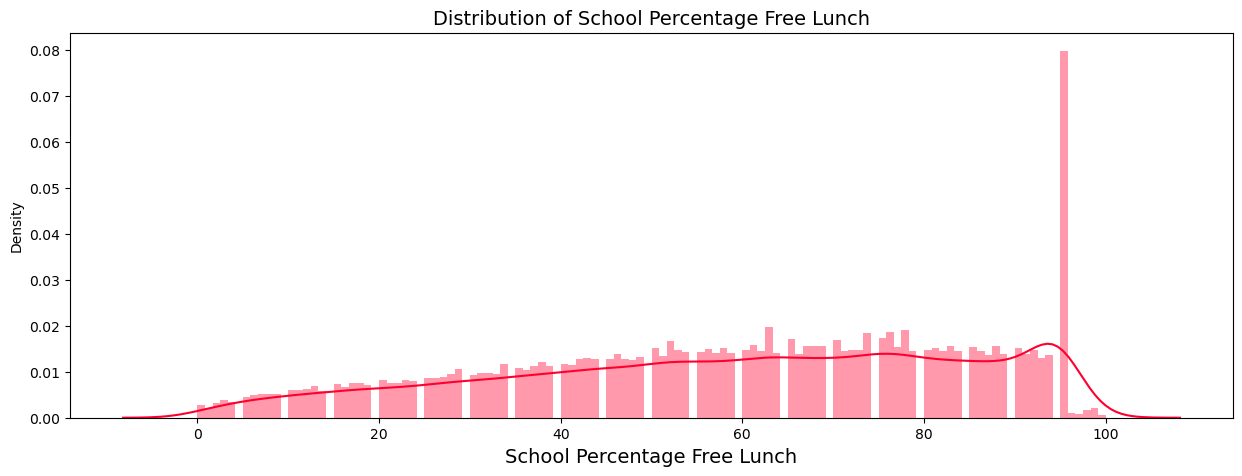

In [34]:
# extract School Types 
plt.figure(figsize=(15,5))
sns.distplot(schools_df['School Percentage Free Lunch'].dropna(), bins=120, color="#ff002e")
plt.xlabel('School Percentage Free Lunch', fontsize=14);
plt.title("Distribution of School Percentage Free Lunch", fontsize=14);
plt.show();

## <a id="5.4">5.4 Qué tipos de escuelas están registradas en mayor cantidad</a>


In [35]:
words = " ".join(schools_df['School Name']).split()
from collections import Counter

school_types = Counter(words).most_common(30)[1:9]
school_types = [list(x) for x in school_types]
labels = [x[0]+" School" for x in school_types]
values = [x[1] for x in school_types]

trace2 = go.Bar(
    x=labels,
    y=values,
    name='Donors to Population',
    marker=dict(color='#ff00bb'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    title = 'School Types Distribution',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

> Una gran mayoría de las escuelas son escuelas primarias, con cerca de 35K escuelas, lo cual es mucho mayor que las preparatorias, con alrededor de 12K escuelas, las secundarias, con cerca de 9K escuelas, o las academias, con alrededor de 4K escuelas.

## <a id="6">6. Exploración de recursos</a>  

Los datos de recursos consisten en artículos solicitados dentro de diferentes proyectos, incluyendo nombre del artículo, cantidad del recurso, precio unitario y nombre del proveedor.

## <a id="6.1">6.1 Vista general de los recursos</a>


In [36]:
resources_df = resources_df.copy()
resources_df.head(5)

# len(resources_df)

,Project ID,Resource Item Name,Resource Quantity,Resource Unit Price,Resource Vendor Name
0,000009891526c0ade7180f8423792063,chair move and store cart,1.0,350.00,NaN
1,00000ce845c00cbf0686c992fc369df4,sony mdr zx100 blk headphones,40.0,12.86,CDW-G
2,00002d44003ed46b066607c5455a999a,"gaiam kids stay-n-play balance ball, grey",4.0,19.00,Amazon Business
3,00002d44003ed46b066607c5455a999a,cf520x - giant comfy pillows - set of 4,1.0,269.00,Lakeshore Learning Materials
4,00002d44003ed46b066607c5455a999a,"serta lounger, mini, sky blue",1.0,131.85,Amazon Business


> Hasta abril de 2018, los maestros han realizado un total de 7,210,448 solicitudes de recursos en distintos proyectos.

## <a id="6.2">6.2 Artículos más populares</a>  

Se identifican los artículos más populares a partir de los datos de recursos. Los artículos más solicitados son aquellos que aparecen en una gran cantidad de proyectos. Los artículos solicitados en grandes cantidades representan recursos pedidos en volumen.

- 6.2.1 Artículos más solicitados de todos los tiempos  
- 6.2.2 Artículos solicitados en grandes cantidades


In [37]:
# Artículos más solicitados
tdf = resources_df['Resource Item Name'].value_counts().head(15)

t = pd.DataFrame({
    'standardized': tdf.index,
    'count': tdf.values
})

t1 = t.sort_values('count', ascending=True)

trace1 = bar_ver_noagg(
    list(t1['standardized']),
    list(t1['count']),
    "Most Requested Resource Items",
    "#ff5479",
    400,
    400,
    0,
    rt=True
)

# Artículos solicitados en mayor cantidad
t2 = resources_df.sort_values(
    'Resource Quantity',
    ascending=False
).head(10)

trace2 = bar_ver_noagg(
    t2['Resource Item Name'],
    t2['Resource Quantity'],
    "Items Requested in Bulk",
    "#fc839d",
    600,
    400,
    0,
    rt=True
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    print_grid=False,
    subplot_titles=[
        'Most Requested Items',
        'Items Requested in Bulk'
    ]
)

fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)

fig['layout'].update(
    height=400,
    showlegend=False,
    margin=dict(b=120)
)

iplot(fig)

> Como se puede observar, el Apple iPad, incluyendo iPad Mini, WiFi, 16 o 32 GB, es el artículo más solicitado de todos los tiempos. Fue solicitado en más de 30 mil proyectos. Los maestros están muy interesados en usar tecnología dentro de las aulas. **Trips** es otro de los artículos más solicitados de todos los tiempos, con más de 20K proyectos, lo cual indica que los maestros están interesados en llevar a los estudiantes a viajes educativos o culturales. Otros artículos principales incluyen Privacy Partition, Commercial Furniture y Soft seats.

> Existen muchos artículos que se solicitan en grandes cantidades en uno o más proyectos. Algunos ejemplos incluyen Polyethylene crosslink blocks, q-ball renewal glide y chair glide.

## <a id="6.3">6.3 Artículos más costosos</a>


In [38]:
t = resources_df.sort_values('Resource Unit Price', ascending=False).head(15)
t1 = pd.DataFrame()
t1['item'] = t['Resource Item Name']
t1['price'] = t['Resource Unit Price']
t1['standardized'] = """Handicapped Playground,Playground,CommercialStructure,Telescopic Gym,Playground+Playsystem,Sound System,CommercialStructure,Wood Playground,Playground+Playsystem,10 Alpha,Leveled Bookroom,Daktronic GS6,Contra Bassoon,Fencing,Playground+Playsystem""".split(",")
t2 = t1.groupby('standardized').agg({'price' : 'max'}).reset_index()
t2 = t2.sort_values('price', ascending = True)
trace2 = bar_ver_noagg(list(reversed(list(t2['standardized']))), list(reversed(list(t2['price']))), "Most Expensive Resource Items", "#69efbc", 800, 400, 100)

> - Algunos de los recursos más costosos en DonorsChoose son los **playgrounds**, como Handicapped Playground, con casi USD 100,000, siendo el recurso más caro, seguido de **Little Tikes Commercial Structure** y **Telescopic Gyms**.

## <a id="6.4">6.4 Proveedores famosos en DonorsChoose</a>


In [39]:
# most famous vendors
t = resources_df['Resource Vendor Name'].value_counts()
k = list(reversed(list(t.index)[:15]))
v = list(reversed(list(t.values)[:15]))

t = resources_df.sort_values('Resource Quantity', ascending=False).head(10)
trace2 = bar_hor_noagg(k, v, "Most Expensive Resource Items", "#4cc0ff", 800, 500, 200, rt=True)

resources_df['total_price'] = resources_df['Resource Quantity'] * resources_df['Resource Unit Price']

# to which vendor has most money went 
# tempdf = resources_df.groupby('Resource Vendor Name').agg({'total_price' : 'sum'}).reset_index()
# tempdf = tempdf.sort_values('total_price', ascending = False)[:10]
# trace1 = bar_hor_noagg(list(reversed(list(tempdf['Resource Vendor Name']))), list(reversed(list(tempdf['total_price']))), "", "#8dd0f4", 600, 400, 200, rt=True)

# average price received by which vendors 
tempdf = resources_df.groupby('Resource Vendor Name').agg({'total_price' : 'mean'}).reset_index()
tempdf = tempdf.sort_values('total_price', ascending = False)[:15]
trace1 = bar_hor_noagg(list(reversed(list(tempdf['Resource Vendor Name']))), list(reversed(list(tempdf['total_price']))), "", "#c1e2f4", 800, 400, 200, rt=True)

fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["Vendor's Total Count" , "Vendor's Average Amount per project"])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace1, 1, 2);
fig['layout'].update(height=600, showlegend=False, margin=dict(l=250));
iplot(fig);

> - La mayoría de los recursos se solicitan a través de **Amazon Business**, con 3.2 millones de ocasiones en las que se pidió un artículo de Amazon. Amazon Business es seguido por Lakeshore Learning Materials y AKJ Education.
> - Al comparar el costo promedio recibido por proveedor, **MarkerBot** aparece en primer lugar, con un costo promedio por proyecto recibido de **USD 2000**.
> - **Best Buy Education** es un proveedor popular entre los maestros y también tiene un precio promedio por proyecto considerablemente más alto.
<br>

## <a id="7">7. Exploración de proyectos</a> 

Los datos de proyectos contienen todos los detalles de los proyectos publicados, incluyendo ID del maestro y de la escuela, título, tipo, categoría, costo, entre otros. A continuación se muestra una vista general.

## <a id="7.1">7.1 Vista general de los proyectos</a>


In [40]:
projects_df = projects_df.copy()
projects_df.head(3)

,Project ID,School ID,Teacher ID,Teacher Project Posted Sequence,Project Type,Project Title,Project Essay,Project Short Description,Project Need Statement,Project Subject Category Tree,Project Subject Subcategory Tree,Project Grade Level Category,Project Resource Category,Project Cost,Project Posted Date,Project Expiration Date,Project Current Status,Project Fully Funded Date
0,7685f0265a19d7b52a470ee4bac883ba,e180c7424cb9c68cb49f141b092a988f,4ee5200e89d9e2998ec8baad8a3c5968,25,Teacher-Led,Stand Up to Bullying: Together We Can!,Did you know that 1-7 students in grades K-12 ...,Did you know that 1-7 students in grades K-12 ...,"My students need 25 copies of ""Bullying in Sch...",Applied Learning,"Character Education, Early Development",Grades PreK-2,Technology,361.80,2013-01-01,2013-05-30,Fully Funded,2013-01-11
1,f9f4af7099061fb4bf44642a03e5c331,08b20f1e2125103ed7aa17e8d76c71d4,cca2d1d277fb4adb50147b49cdc3b156,3,Teacher-Led,Learning in Color!,"Help us have a fun, interactive listening cent...","Help us have a fun, interactive listening cent...","My students need a listening center, read alon...","Applied Learning, Literacy & Language","Early Development, Literacy",Grades PreK-2,Technology,512.85,2013-01-01,2013-05-31,Expired,NaN
2,afd99a01739ad5557b51b1ba0174e832,1287f5128b1f36bf8434e5705a7cc04d,6c5bd0d4f20547a001628aefd71de89e,1,Teacher-Led,Help Second Grade ESL Students Develop Languag...,Visiting or moving to a new place can be very ...,Visiting or moving to a new place can be very ...,My students need beginning vocabulary audio ca...,Literacy & Language,ESL,Grades PreK-2,Supplies,435.92,2013-01-01,2013-05-30,Fully Funded,2013-05-22


## <a id="7.2">7.2 Cuáles son las categorías, subcategorías y categorías de recursos más frecuentes en los proyectos publicados</a>


In [41]:
# Create some date time features 
projects_df['Posted Date'] = pd.to_datetime(projects_df['Project Posted Date'])

projects_df['Posted Year'] = projects_df['Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Posted Date'].dt.month
projects_df['Posted Day'] = projects_df['Posted Date'].dt.weekday
projects_df['Posted Quarter'] = projects_df['Posted Date'].dt.quarter

projects_df['Funded Date'] = pd.to_datetime(projects_df['Project Fully Funded Date'])
projects_df['Funded Year'] = projects_df['Funded Date'].dt.year
projects_df['Funded Month'] = projects_df['Funded Date'].dt.month
projects_df['Funded Day'] = projects_df['Funded Date'].dt.weekday
projects_df['Funded Quarter'] = projects_df['Funded Date'].dt.quarter
projects_df['Funding Time'] = projects_df['Funded Date'] - projects_df['Posted Date']



t = projects_df['Project Subject Category Tree'].value_counts()
x = list(t.index)
y = list(t.values)
r = {}
for i,val in enumerate(x):
    for each in val.split(","):
        x1 = each.strip()
        if x1 not in r:
            r[x1] = y[i]
        r[x1] += y[i]
sorted_x = list(sorted(r.items(), key=operator.itemgetter(1), reverse = True))[:10]
x1 = [a[0] for a in sorted_x][::-1]
y1 = [a[1] for a in sorted_x][::-1]



t1 = projects_df['Project Subject Subcategory Tree'].value_counts()
x2 = list(t1.index)
y2 = list(t1.values)
r = {}
for i,val in enumerate(x2):
    for each in val.split(","):
        x1_ = each.strip()
        if x1_ not in r:
            r[x1_] = y2[i]
        r[x1_] += y2[i]        
x2 = r.keys()
y2 = r.values()
sorted_x = list(sorted(r.items(), key=operator.itemgetter(1), reverse = True))[:10]
x2 = [a[0] for a in sorted_x][::-1]
y2 = [a[1] for a in sorted_x][::-1]

t = projects_df['Project Resource Category'].value_counts()
x3 = list(t.index[::-1])[:10]
y3 = list(t.values[::-1])[:10]


trace1 = bar_hor_noagg(x1, y1, "", "#8cf2a9", 600, 400, 10, rt=True)
trace2 = bar_hor_noagg(x2, y2, "", "#8cf2a9", 600, 400, 10, rt=True)
trace3 = bar_hor_noagg(x3, y3, "", "#8cf2a9", 600, 400, 10, rt=True)

fig = tools.make_subplots(rows=1, cols=5, print_grid=False, subplot_titles = ['Project Categories' ,"", 'Project Subcategories', '', "Resource Categories"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 3);
fig.append_trace(trace3, 1, 5);
fig['layout'].update(height=400, showlegend=False, margin=dict(l=120));
iplot(fig);

> Una gran mayoría de los proyectos, más de 800K, pertenecen a la categoría principal de **Literacy and Language**. **Math and Science** es la segunda categoría más común. Desde 2013 se ha publicado una cantidad comparativamente menor de proyectos sobre Care and Hunger.  
> Entre las subcategorías, Literacy, Mathematics y Writing son las más comunes dentro de los proyectos publicados por los maestros, mientras que se publican menos proyectos bajo Early Development y Health.
> **Instructional Technology, Reading Nooks, Desks and Storage** son categorías clave de recursos solicitados por los maestros.

## <a id="7.3">7.3 Cuál es la distribución del tipo de proyecto y del estado actual del proyecto</a>


In [42]:
t = projects_df['Project Type'].value_counts()
values1 = t.values 
index1 = t.index
t = projects_df['Project Current Status'].value_counts()
values2 = t.values 
index2 = t.index


domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}


fig = {
  "data": [
    {
      "values": values1,
      "labels": index1,
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2']),
      "name": "Project Type",
      "hoverinfo":"label+percent+name",
      "hole": .7,
        
      "type": "pie"
    },
    {
      "values": values2,
      "labels": index2,
        "marker" : dict(colors=[ "#efbc56", "#81a7e8", "#e295d0"]),
      "domain": {"x": [.52, 1]},
        "text":["CO2"],
      "textposition":"inside",
      "name": "Project Status",
#         "text" : values2t,
#         "textinfo" : "text",
        "hole" : .7,
      "type": "pie"
    }],
  "layout": {
#         "title":"Project Type and Project Status",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Type",
                "x": 0.21,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Status",
                "x": 0.8,
                "y": 0.5
            }
        ]
    
    }
}
iplot(fig, filename='donut')

> Además de los proyectos dominantes dirigidos por maestros, también se publican en menor cantidad proyectos de estudiantes o servicios de desarrollo profesional. Los datos muestran que alrededor del 75% de todos los proyectos publicados han sido financiados completamente, mientras que el 21% expiró. Hasta mayo de 2018, aproximadamente 42K proyectos permanecen activos en DonorsChoose.

## <a id="7.4">7.4 En qué días se publicaron y financiaron más proyectos?</a>


In [43]:
t1 = projects_df['Posted Day'].value_counts()
t2 = projects_df['Funded Day'].value_counts()

mapp = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}
values1 = t1.values 
index1 = t1.index
index1 = [mapp[x] for x in index1]

values2 = t2.values 
index2 = t2.index
index2 = [mapp[x] for x in index2]
tmap = {}
for j, b in enumerate(index2):
    tmap[b] = values2[j]
# print (tmap)
# print index1
values2_c = [tmap[c] for c in index1]
# print values2_c
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}


fig = {
  "data": [
    {
      "values": values1,
      "labels": index1,
      "domain": {"x": [0, .48]},
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "name": "PostedDay",
      "hoverinfo":"label+percent+name",
      "hole": .7,
#             "textinfo" : "text",
      "type": "pie"
    },
    {
      "values": values2_c,
      "labels": index1,
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "domain": {"x": [.52, 1]},
#         "text":"CO2",
      "textposition":"inside",
      "name": "FundedDay",
#         "text" : values2,
#         "textinfo" : "text",
        "hole" : .7,
      "type": "pie"
    }],
  "layout": {
#         "title":"Project Type and Project Status",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "PostedDay",
                "x": 0.17,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "FundedDay",
                "x": 0.83,
                "y": 0.5
            }
        ]
    
    }
}
iplot(fig, filename='donut')

> Generalmente, los maestros publicaron más proyectos al final de la semana: viernes (16%), sábado (16%) y domingo (17%). Por otro lado, los lunes se financió y cerró la mayor cantidad de proyectos.

## <a id="7.5">7.5 En qué trimestres se publican y financian los proyectos?</a>


In [44]:
t1 = projects_df['Posted Quarter'].value_counts()
t2 = projects_df['Funded Quarter'].value_counts()

mappq = {1.0:'Quarter 1',2.0:'Quarter 2',3.0:'Quarter 3',4.0:'Quarter 4'}
values1 = t1.values 
index1 = t1.index
index1 = [mappq[x] for x in index1]

values2 = t2.values 
index2 = t2.index
index2 = [mappq[x] for x in index2]
tmap = {}
for j, b in enumerate(index2):
    tmap[b] = values2[j]
# print (tmap)
# print index1
values2_c = [tmap[c] for c in index1]
# print values2_c
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}


fig = {
  "data": [
    {
      "values": values1,
      "labels": index1,
      "domain": {"x": [0, .48]},
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "name": "PostedDay",
#       "hoverinfo":"label+percent+name",
      "hole": .7,
#             "textinfo" : "text",
      "type": "pie"
    },
    {
      "values": values2_c,
      "labels": index1,
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "domain": {"x": [.52, 1]},
#         "text":"CO2",
      "textposition":"inside",
      "name": "FundedDay",
#         "text" : values2,
#         "textinfo" : "text",
        "hole" : .7,
      "type": "pie"
    }],
  "layout": {
#         "title":"Project Type and Project Status",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Posted",
                "x": 0.2,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Funded",
                "x": 0.8,
                "y": 0.5
            }
        ]
    
    }
}
iplot(fig, filename='donut')




> El trimestre 3, es decir, julio, agosto y septiembre, es el periodo en el que los maestros publicaron la mayor cantidad de proyectos. De forma similar, el trimestre inmediato siguiente, el trimestre 4, fue cuando la mayoría de los proyectos se financiaron y cerraron.

## <a id="7.6">7.6 En qué meses se publicaron los proyectos?</a>


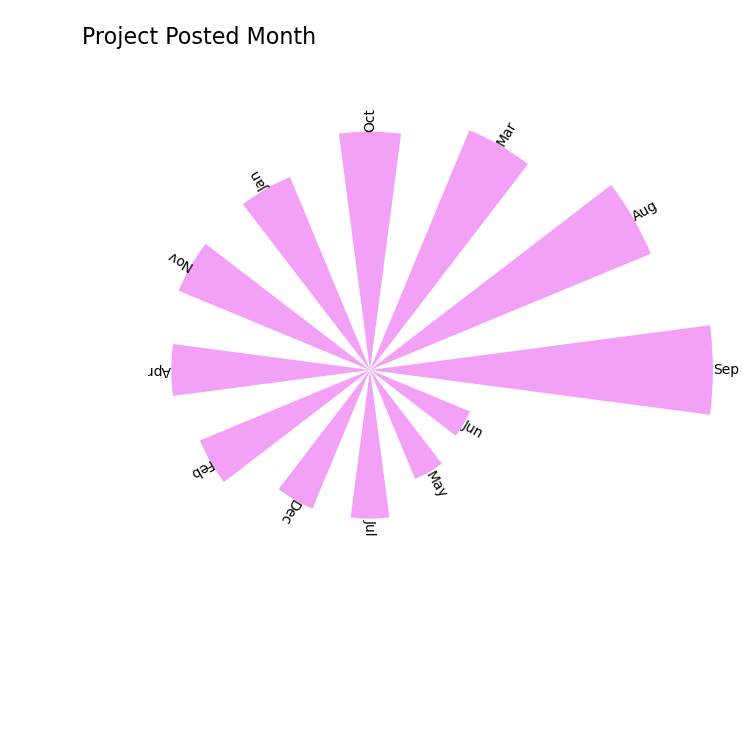

In [45]:
t = projects_df['Posted Month'].value_counts()


lObjectsALLcnts = list(t.values)

lObjectsALLlbls = list(t.index)
mapp1 = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
lObjectsALLlbls = [mapp1[x] for x in lObjectsALLlbls]

iN = len(lObjectsALLcnts)
arrCnts = np.array(lObjectsALLcnts)

theta=np.arange(0, 2*np.pi, 2*np.pi/iN)
width = (2*np.pi)/iN *0.5
bottom = 50

fig = plt.figure(figsize=(8,8))
ax = fig.add_axes([0.2, 0.1, 1, 0.9], polar=True)
fig.suptitle('Project Posted Month   ', fontsize=16)
bars = ax.bar(theta, arrCnts, width=width, bottom=bottom, color='#f3a0f7')
plt.axis('off')

rotations = np.rad2deg(theta)
for x, bar, rotation, label in zip(theta, bars, rotations, lObjectsALLlbls):
    lab = ax.text(x,bottom+bar.get_height() , label, ha='left', va='center', rotation=rotation, rotation_mode="anchor",)   
plt.show()


> En el trimestre 3, la mayor cantidad de proyectos se publicó en septiembre, seguido de agosto. La menor cantidad de proyectos se publicó en junio.

## <a id="7.7">7.7 En qué año se publicaron los proyectos?</a>


In [46]:
t = projects_df.groupby('Posted Year').agg({'Posted Month' : 'count'}).reset_index()
t = t.sort_values('Posted Year')
trace2 = bar_ver_noagg(t['Posted Year'], t['Posted Month'], "", "#9887ed", None, 400, 0)


> El número de proyectos en DonorsChoose ha aumentado constantemente durante los últimos 5 años. Cerca de 300K proyectos fueron publicados en 2017.

## <a id="7.8">7.8 En qué año y mes el costo del proyecto es más alto?</a>


In [47]:
year_tab = pd.crosstab(projects_df["Project Current Status"], projects_df["Posted Year"]).reset_index()
from itertools import zip_longest
projects_df['cost'] = projects_df['Project Cost'].apply(lambda x : float(str(x).replace(",","").replace("$","")))

def cbp(df, col1, col2, aggcol, func, title, cs, bottom_margin=None):
    tempdf = df.groupby([col1, col2]).agg({aggcol : func}).reset_index()
    tempdf[aggcol] = tempdf[aggcol].apply(lambda x : int(x))
    tempdf = tempdf.sort_values(aggcol, ascending=False)

    sizes = list(reversed([i for i in range(10,31)]))
    intervals = int(len(tempdf) / len(sizes))
    size_array = [9]*len(tempdf)
    
    st = 0
    for i, size in enumerate(sizes):
        for j in range(st, st+intervals):
            size_array[j] = size 
        st = st+intervals
    tempdf['size_n'] = size_array
    # tempdf = tempdf.sample(frac=1).reset_index(drop=True)

    cols = list(tempdf['size_n'])

    trace1 = go.Scatter( x=tempdf[col1], y=tempdf[col2], mode='markers', text=tempdf[aggcol],
        marker=dict( size=tempdf.size_n, color=cols, colorscale=cs ))
    data = [trace1]
    if bottom_margin:
        layout = go.Layout(title=title, margin=dict(b=150))
    else:
        layout = go.Layout(title=title)
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

cbp(projects_df, 'Posted Month', 'Posted Year', 'cost', 'mean', '', 'Picnic')



> - En septiembre de 2014 se observó una gran cantidad de proyectos publicados con costo promedio alto. En 2015, los meses de abril, mayo, septiembre y octubre tuvieron proyectos con costos elevados.

## <a id="7.9">7.9 En qué año y categoría de grado el costo del proyecto es más alto?</a>


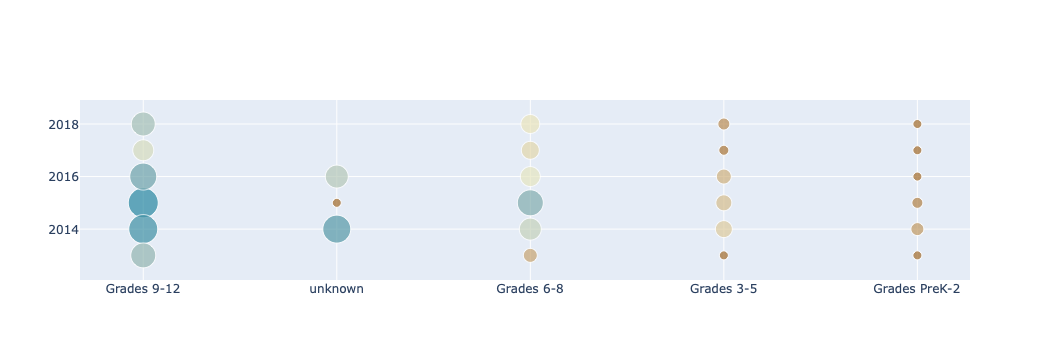

In [48]:
cbp(projects_df, 'Project Grade Level Category', 'Posted Year', 'cost', 'mean', '', 'Earth')

> Para los grados 6-8 y 9-12, los proyectos con costos altos se presentaron en el año 2015. Para los grados 3-5 y PreK-2, estos se presentaron en 2014.

## <a id="7.10">7.10 Categorías de grado y categorías de recursos con los costos de proyecto más altos</a>


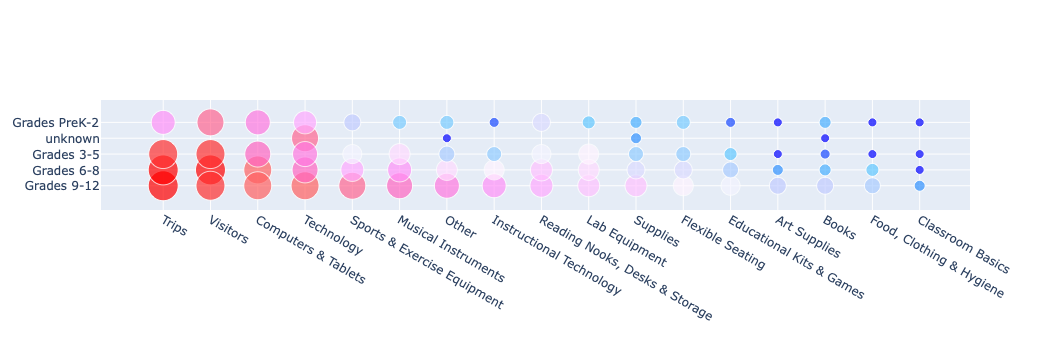

In [49]:
cbp(projects_df, 'Project Resource Category', 'Project Grade Level Category', 'cost', 'mean', '', 'Picnic', bottom_margin=150)

> - Los viajes se organizan principalmente para grados superiores, es decir, 9-12, seguidos de 6-8 y después 3-5. Los grados PreK-2 tienen una cantidad significativamente menor en comparación con otros grados. Visitors es otra categoría clave de recursos para todos los grados.

## <a id="7.11">7.11 Cómo varía el estado del proyecto por año?</a>


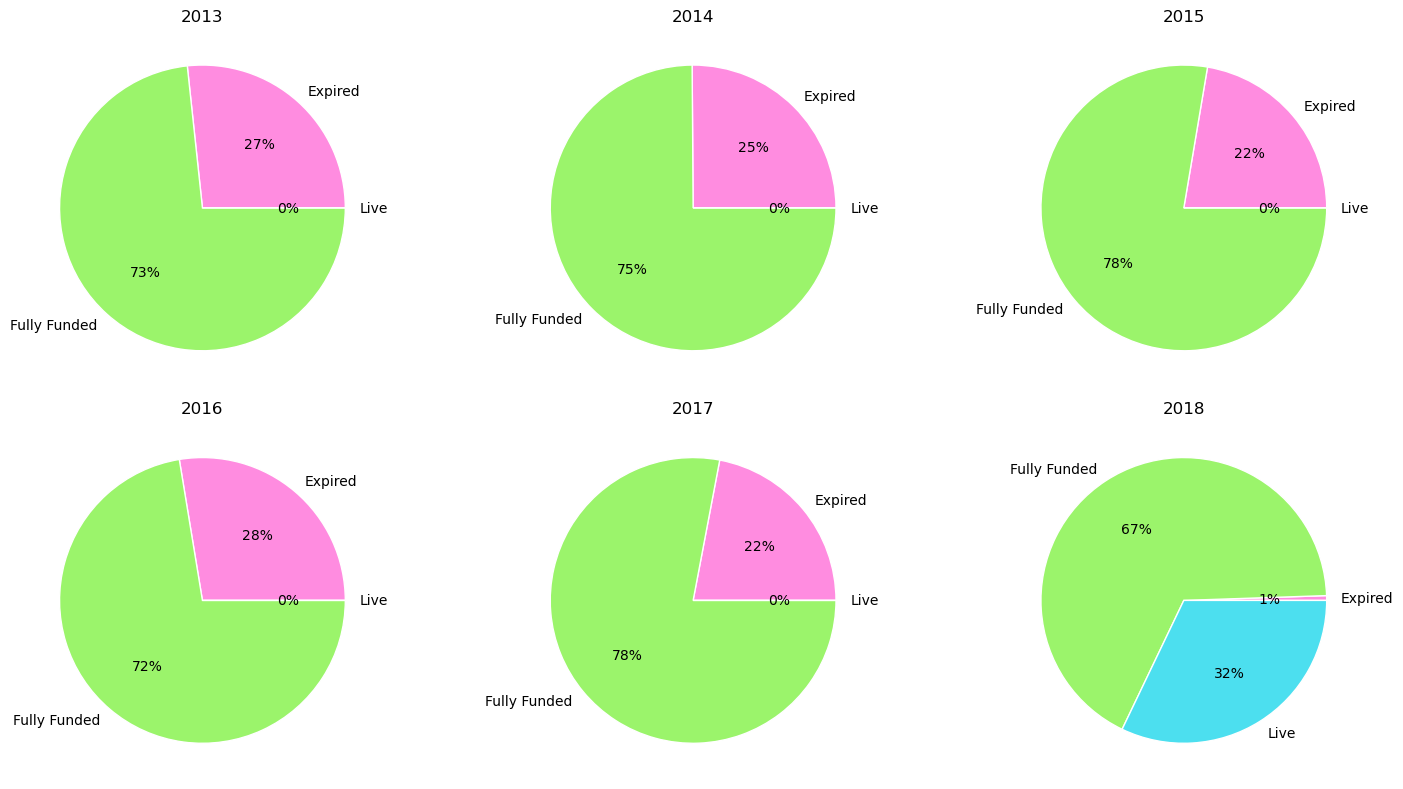

In [50]:
# Estado de los proyectos por año

projects_df['Project Posted Date'] = pd.to_datetime(
    projects_df['Project Posted Date'],
    errors='coerce'
)

year_tab = pd.crosstab(
    projects_df['Project Posted Date'].dt.year,
    projects_df['Project Current Status']
)

years = year_tab.index.tolist()

plt.figure(figsize=(15, 8))

for j, year in enumerate(years):
    plt.subplot(2, 3, j + 1)

    valores = year_tab.loc[year]

    plt.pie(
        valores.values,
        labels=year_tab.columns.tolist(),
        autopct="%1.0f%%",
        colors=["#ff8ce0", "#9bf46b", "#4cdfef"],
        wedgeprops={"linewidth": 1, "edgecolor": "white"}
    )

    plt.title(str(int(year)))

plt.tight_layout()
plt.show()

> Una revisión año por año de los datos muestra que **alrededor del 70% del total de proyectos** publicados en DonorsChoose en un año son financiados completamente. Existe una tendencia creciente en el porcentaje de proyectos financiados completamente por año, **excepto en 2016**, cuando el número de proyectos financiados completamente disminuyó 6% respecto al año anterior. 2017 y 2015 fueron los mejores años en términos de proporción de proyectos financiados completamente, con alrededor del **78% de los proyectos** financiados.

## <a id="7.12">7.12 Durante cuántos días permanecieron activos los proyectos?</a>


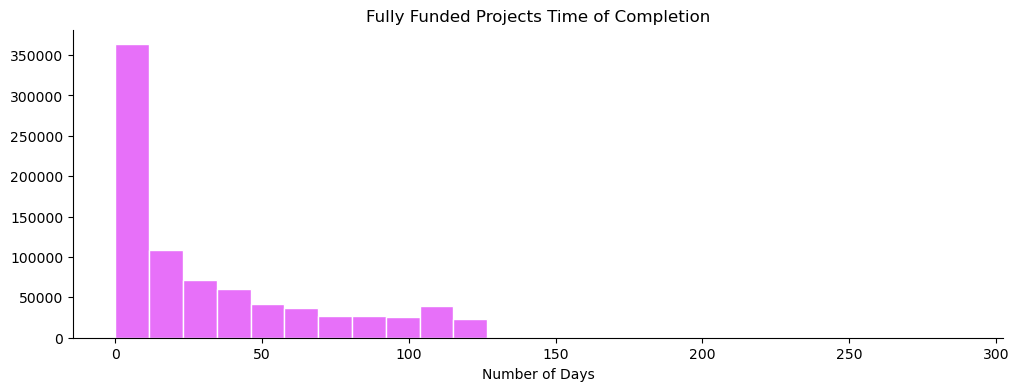

In [51]:
t = projects_df[projects_df['Project Current Status'] == "Fully Funded"]
t['Funding Time'] = t['Funding Time'].apply(lambda x : int(str(x).split()[0]))

plt.figure(figsize=(12,4));
ax = t['Funding Time'].hist(bins=25, edgecolor='white', color="#e770f9")
ax.grid(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
plt.xlabel('Number of Days');
plt.title('Fully Funded Projects Time of Completion');

> - Una gran cantidad de proyectos tiene un tiempo de finalización menor a 3 días. Cerca de <b>"55,000 proyectos"</b> en el pasado fueron financiados exitosamente en un día, mientras que hay aproximadamente <b>"48,627 proyectos"</b> que se cerraron el mismo día en que fueron publicados. El número máximo de días para un proyecto fue de 288 días, correspondiente al proyecto titulado "**Empty Bowls, Full Hearts.**". Este proyecto tenía un costo estimado de USD 1982 y fue publicado por **Harrison Park Elementary School** en Michigan.

## <a id="7.13">7.13 Cómo varía la proporción de proyectos financiados y no financiados por estado?</a>


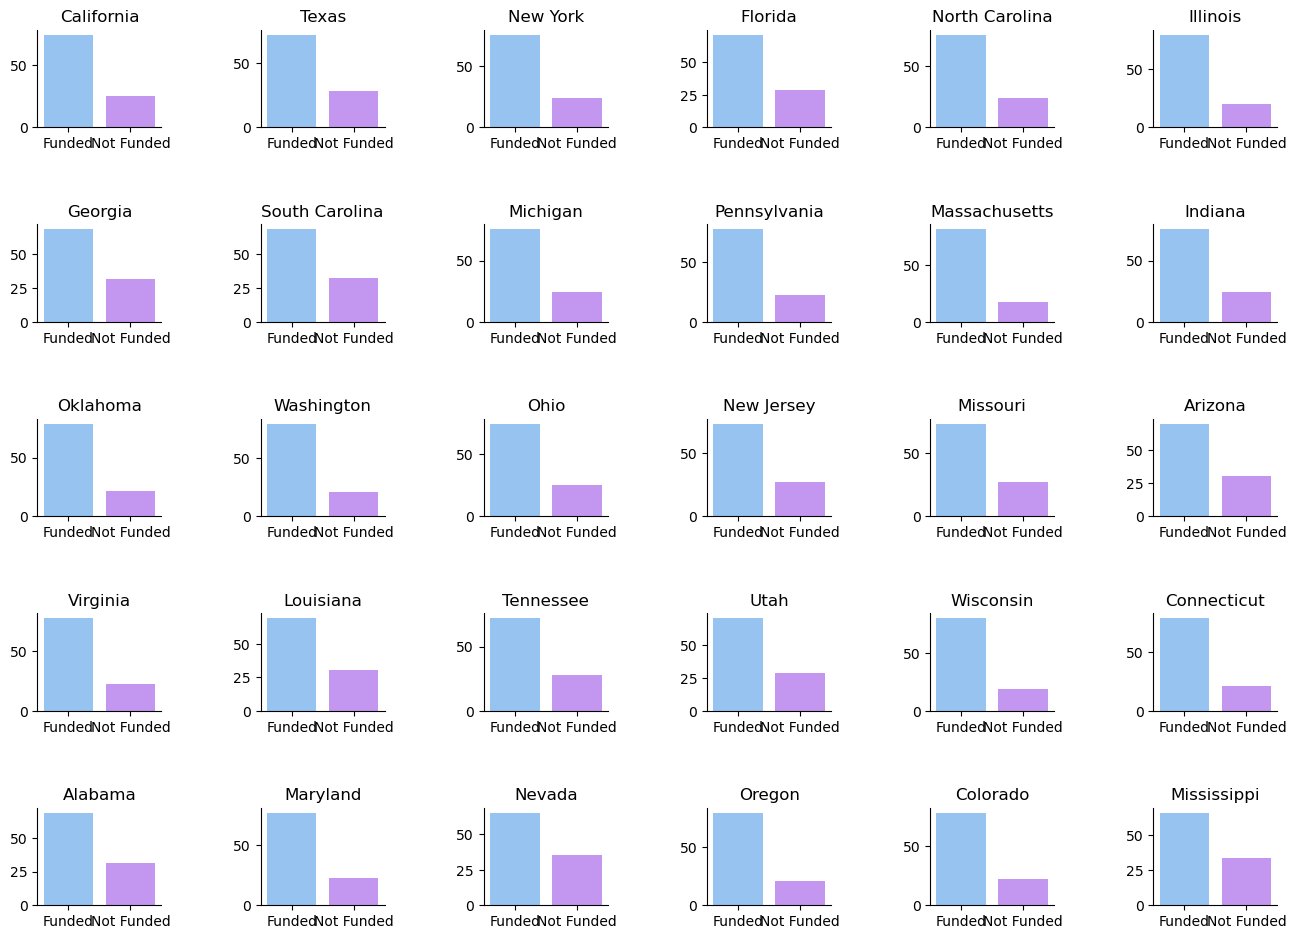

In [52]:
projsch_df = projects_df.merge(schools_df, on="School ID")

states = [
    u'California', u'Texas', u'New York', u'Florida', u'North Carolina',
    u'Illinois', u'Georgia', u'South Carolina', u'Michigan',
    u'Pennsylvania', u'Massachusetts', u'Indiana', u'Oklahoma',
    u'Washington', u'Ohio', u'New Jersey', u'Missouri', u'Arizona',
    u'Virginia', u'Louisiana', u'Tennessee', u'Utah', u'Wisconsin',
    u'Connecticut', u'Alabama', u'Maryland', u'Nevada', u'Oregon',
    u'Colorado', u'Mississippi'
]

import itertools

length = len(states)

plt.figure(figsize=(16, 24))

for i, j in itertools.zip_longest(states, range(length)):
    plt.subplot(10, 6, j + 1)

    t = dict(
        projsch_df[
            projsch_df['School State'] == i
        ]['Project Current Status'].value_counts()
    )

    funded = t.get('Fully Funded', 0)
    expired = t.get('Expired', 0)

    # Estados que no están completamente financiados
    not_funded = (
        expired
        + t.get('Live', 0)
        + t.get('Proposed', 0)
    )

    total = funded + not_funded

    if total == 0:
        plt.title(i, color="black")
        plt.axis("off")
        continue

    t1 = {
        'Funded': funded * 100 / total,
        'Not Funded': not_funded * 100 / total
    }

    ax = sns.barplot(
        x=list(t1.keys()),
        y=list(t1.values()),
        alpha=.7,
        palette='cool'
    )

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.title(i, color="black")

plt.subplots_adjust(wspace=.8, hspace=1)
plt.show()

> - Algunos de los estados donde el porcentaje de proyectos expirados o no financiados es menor son "Georgia", "South Carolina" y "Mississippi".

## <a id="7.14">7.14 Cuál es el costo promedio de los proyectos por tipo de zona escolar y categoría de recurso solicitado?</a>


In [53]:
cbp(projsch_df, 'Project Resource Category', 'School Metro Type', 'cost', 'mean', '', 'Rainbow', bottom_margin = 150)

> Trips y Visitors son siempre las categorías más costosas entre los distintos tipos de zona escolar. "Towns" tiene el costo promedio máximo para proyectos en los que se solicitaron recursos pertenecientes a Sports and Exercise Equipments.

## <a id="7.15">7.15 Cuál es el costo promedio de los proyectos por tipo de zona escolar y categoría de grado?</a>


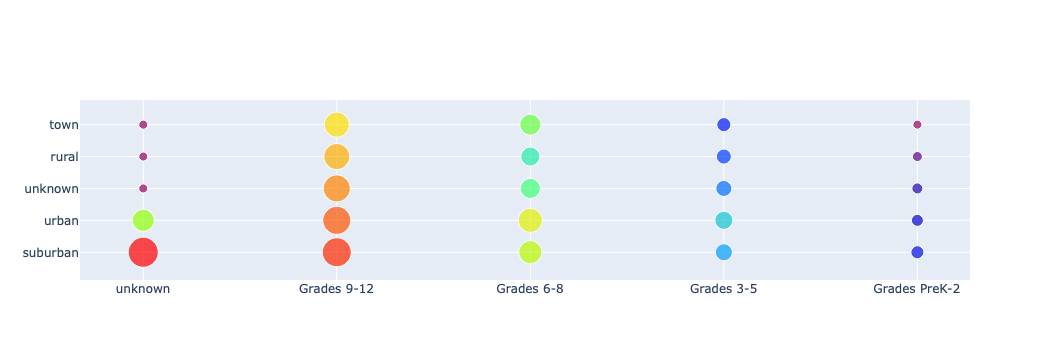

In [54]:
cbp(projsch_df, 'Project Grade Level Category', 'School Metro Type', 'cost', 'mean', '', 'Rainbow')

> Los grados 9-12 tienen el costo promedio de proyecto más alto en comparación con cualquier otra categoría de grado. Entre ellos, los tipos de zona SubUrban tienen los precios de proyecto más altos, mientras que towns presentan los más bajos.

## <a id="8">8. Procesamiento de lenguaje natural para el perfilamiento de proyectos</a>

Se puede obtener mucho entendimiento mediante el análisis de texto de los ensayos de los proyectos. A continuación se realiza un análisis básico de texto y procesamiento de lenguaje natural para extraer información relevante de los ensayos. Para este propósito, se utiliza un subconjunto de proyectos recientes de abril de 2018.

## <a id="8.1">8.1 Limpieza de texto</a>

Se escribe una función de utilidad que normaliza el texto y elimina ruido. Esta función de limpieza elimina palabras vacías del texto y signos de puntuación.


In [55]:
%pip install textblob nltk

Note: you may need to restart the kernel to use updated packages.


In [56]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/farias/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/farias/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [57]:
from textblob import TextBlob
import string
import pandas as pd

try:
    from nltk.corpus import stopwords as nltk_stopwords
    stopwords = set(nltk_stopwords.words("english"))
except Exception:
    stopwords = {
        "the", "and", "a", "an", "to", "of", "in", "for",
        "is", "are", "my", "our", "with", "on", "that",
        "this", "it", "as", "at", "by", "from"
    }

def _clean(txt):
    # Evita errores si hay valores vacíos
    if pd.isna(txt):
        return ""

    txt = str(txt).lower()

    # Quitar puntuación
    txt = ''.join(x for x in txt if x not in string.punctuation)

    # Quitar stopwords
    clean_words = []

    for word in txt.split():
        if word not in stopwords:
            clean_words.append(word)

    clean_txt = " ".join(clean_words)

    noise = [
        'students', 'my', 'title', 'would', 'every',
        'will', 'many', 'also', 'donotremoveessaydivider'
    ]

    for ns in noise:
        clean_txt = clean_txt.replace(ns, "")

    return clean_txt.strip()


# Unir proyectos con escuelas solo si aún no se han unido
if 'School State' not in projects_df.columns:
    projects_df = projects_df.merge(
        schools_df,
        on='School ID',
        how='inner'
    )

# Asegurar que la fecha sea tipo datetime
projects_df['Project Posted Date'] = pd.to_datetime(
    projects_df['Project Posted Date'],
    errors='coerce'
)

projects_df['Posted Year'] = projects_df['Project Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Project Posted Date'].dt.month

# Filtrar proyectos publicados en abril de 2018
april18_df = projects_df[
    (projects_df['Posted Year'] == 2018) &
    (projects_df['Posted Month'] == 4)
].copy()

# Limpiar ensayo
if 'Project Essay' in april18_df.columns:
    april18_df['clean_essay'] = april18_df['Project Essay'].apply(_clean)
else:
    april18_df['clean_essay'] = ""

# Tu dataset no tiene Project Need Statement.
# Usamos Project Essay como respaldo.
if 'Project Need Statement' in april18_df.columns:
    april18_df['clean_need'] = april18_df[
        'Project Need Statement'
    ].apply(_clean)
else:
    april18_df['clean_need'] = april18_df['clean_essay']

april18_df[['clean_essay', 'clean_need']].head()

,clean_essay,clean_need
1067309,third year new beautiful charter school excit...,need science materials love magnifying glasse...
1067310,school 1 atrisk school population 70 english ...,need mats tumble stunt practice cheers
1067311,teach high poverty school 90 receive free red...,need books money money poster games increase n...
1067312,classroom form developmental delay different a...,need scholastic magazines help science classro...
1067313,school neighborhood school – campus nestled oa...,need two standing desks flexible seating optio...


## <a id="8.2">8.2 Análisis de bolsa de palabras</a> 

## <a id="8.2.1">8.2.1 Cuáles son las palabras y frases principales utilizadas por los maestros en los ensayos?</a>


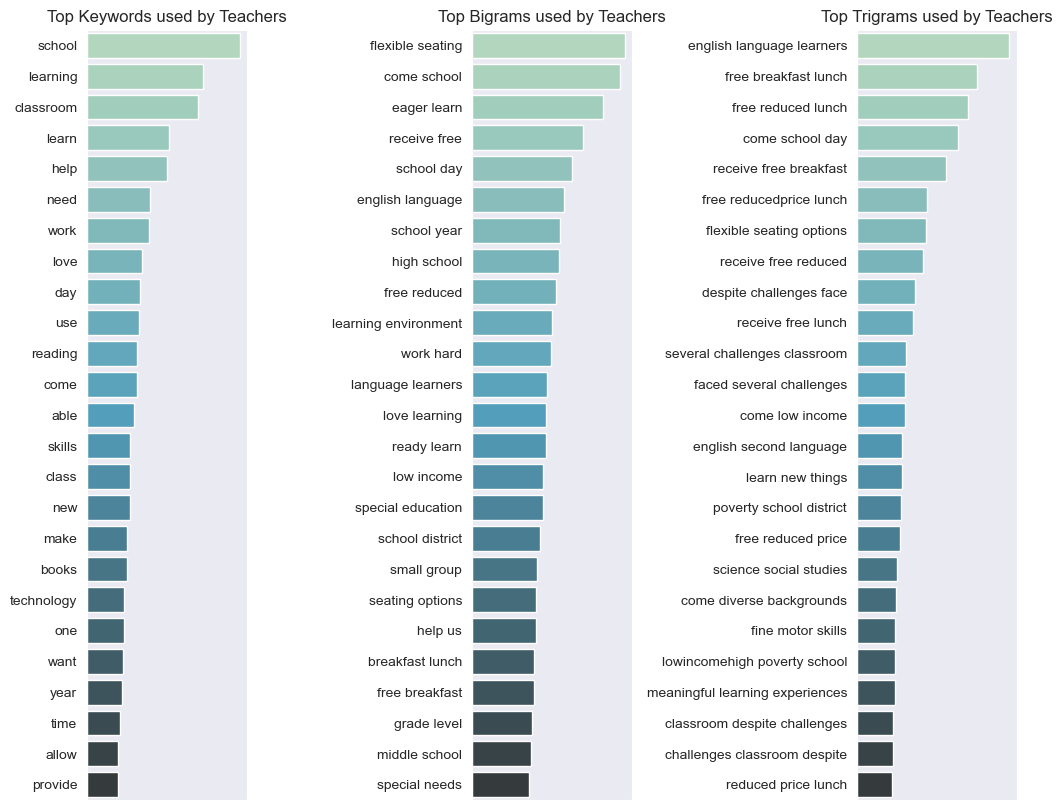

In [58]:
### Bag of Words 
from collections import Counter
def generate_ngrams(txt, N):
    grams = [txt[i:i+N] for i in range(len(txt)-N+1)]
    grams = [" ".join(b) for b in grams]
    return grams 

april18_df['unigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 1))
april18_df['bigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 2))
april18_df['trigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 3))

all_unigrams = []
for each in april18_df['unigrams']:
    all_unigrams.extend(each)
t = Counter(all_unigrams).most_common(25)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df['bigrams']:
    all_bigrams.extend(each)
t1 = Counter(all_bigrams).most_common(25)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]


all_trigrams = []
for each in april18_df['trigrams']:
    all_trigrams.extend(each)
t2 = Counter(all_trigrams).most_common(25)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,10));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top Keywords used by Teachers");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top Bigrams used by Teachers");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top Trigrams used by Teachers");

> Las palabras clave más utilizadas en todos los ensayos, estados y tipos de escuela son <b>"school", "learning", "classroom", "reading"</b>. En los bigramas aparece un enfoque principal en <b>"flexible seating"</b> y <b>"english language"</b>. Una gran cantidad de ensayos de maestros tratan sobre <b>"Free Breakfast and Lunch"</b>, <b>"learning english language"</b> y <b>"several challenges faced"</b>.

## <a id="8.2.2">8.2.2 Cómo varían las frases principales utilizadas por estado?</a>


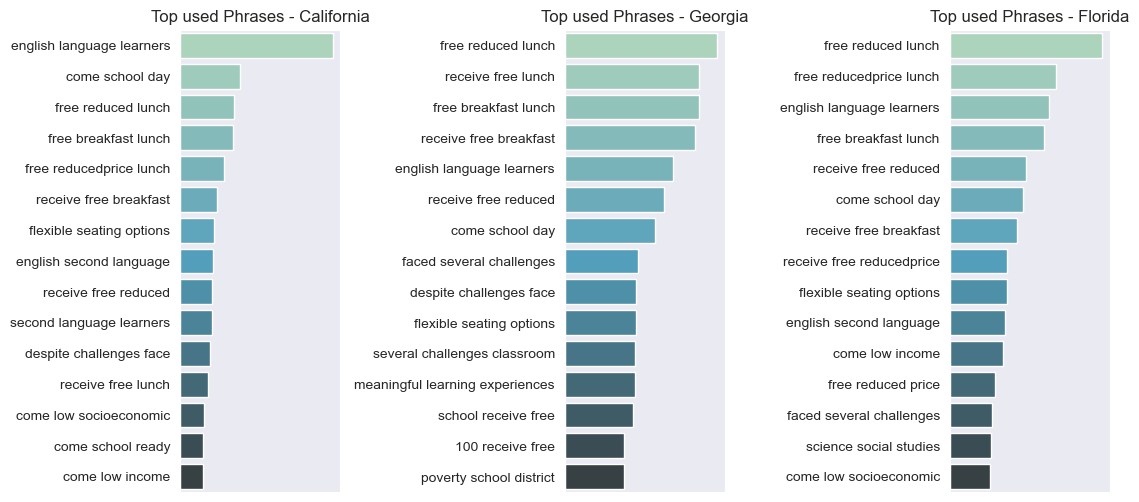

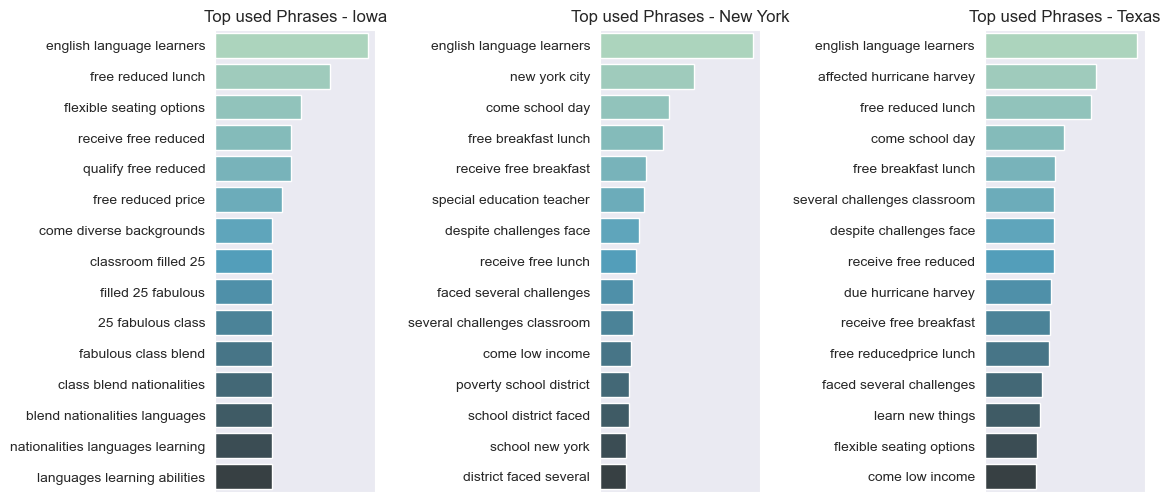

In [59]:
ignores = ['every day', 'come school']
all_unigrams = []
for each in april18_df[april18_df['School State'] == 'California']['trigrams']:
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'Georgia']['trigrams']:
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Florida']['trigrams']:
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top used Phrases - California");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top used Phrases - Georgia");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top used Phrases - Florida");

all_unigrams = []
for each in april18_df[april18_df['School State'] == 'Iowa']['trigrams']:
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'New York']['trigrams']:
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Texas']['trigrams']:
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top used Phrases - Iowa");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Top used Phrases - New York");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Top used Phrases - Texas");

> - El enfoque principal de los ensayos en los distintos estados es muy similar, aunque se observan algunas diferencias en estados como Texas, donde muchos ensayos tratan sobre <b>estudiantes afectados por el huracán Harvey</b>. Los maestros describen "varios desafíos enfrentados" por los estudiantes. <b>"Flexible Seating Options"</b> es uno de los enfoques principales de la mayoría de los ensayos.
> - En Iowa, los maestros describen a <b>"estudiantes que provienen de distintos contextos"</b> y <b>"diferentes nacionalidades"</b>. En Nueva York, los ensayos también se enfocan en <b>"maestros de educación especial"</b>, <b>"escuelas de distritos con pobreza"</b> y <b>"bajos ingresos"</b>.
> - En Florida, los maestros mencionan <b>"precios reducidos de desayuno y almuerzo"</b>.

## <a id="8.2.3">8.2.3 "<i>Mis estudiantes son ______ ______ ______</i>": Qué describen los maestros sobre sus estudiantes?</a>


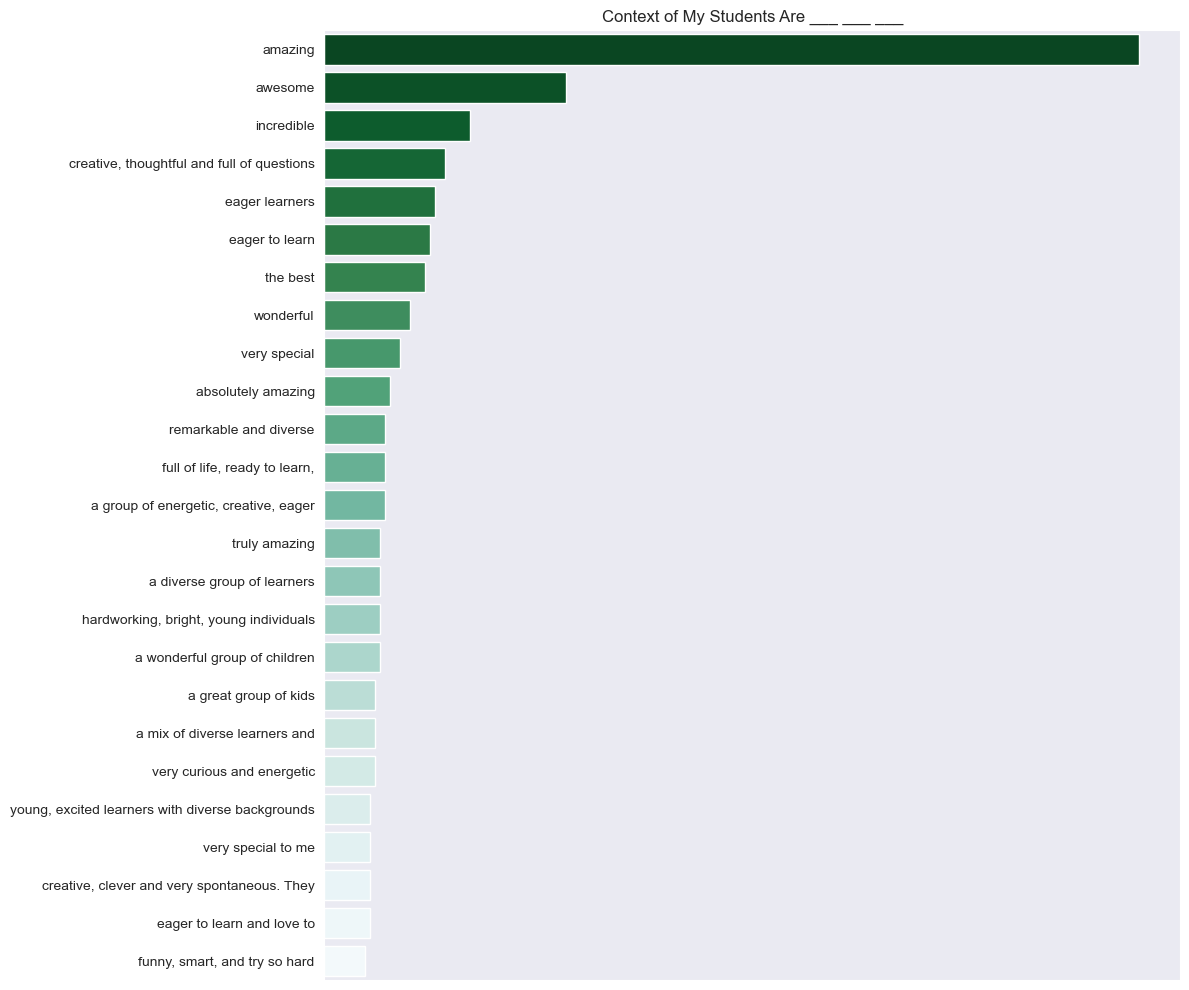

In [60]:
from textblob import TextBlob, Word
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

mystudents = []

for x in april18_df['Project Essay'].dropna():
    x = str(x)

    if x.lower().startswith("my students are"):
        frase = x.replace("My students are", "", 1)

        # Tomar solo la primera oración
        frase = frase.split(". ")[0]
        frase = frase.split("!")[0]

        # Máximo seis palabras
        frase = " ".join(frase.strip().split()[:6])

        if frase:
            mystudents.append(frase)

t3 = Counter(mystudents).most_common(25)

x = [a[0] for a in t3]
y = [a[1] for a in t3]

sns.set_style("dark")

plt.figure(figsize=(12, 10))
plt.title("Context of My Students Are ___ ___ ___")

bar = sns.barplot(
    y=x,
    x=y,
    palette="BuGn_r",
    edgecolor="white"
)

bar.set(xlabel="", xticks=[])

plt.tight_layout()
plt.show()

> - Los maestros utilizaron muchos descriptores para hablar de sus estudiantes, por ejemplo <b>"amazing", "awesome", "incredible", "creative"</b>. En algunos ensayos, los maestros describen a sus estudiantes como <b>"muy especiales para ellos" y "remarkables"</b>.

## <a id="8.2.4">8.2.4 Según los maestros, qué necesitan los estudiantes ______ ______ ______?</a>


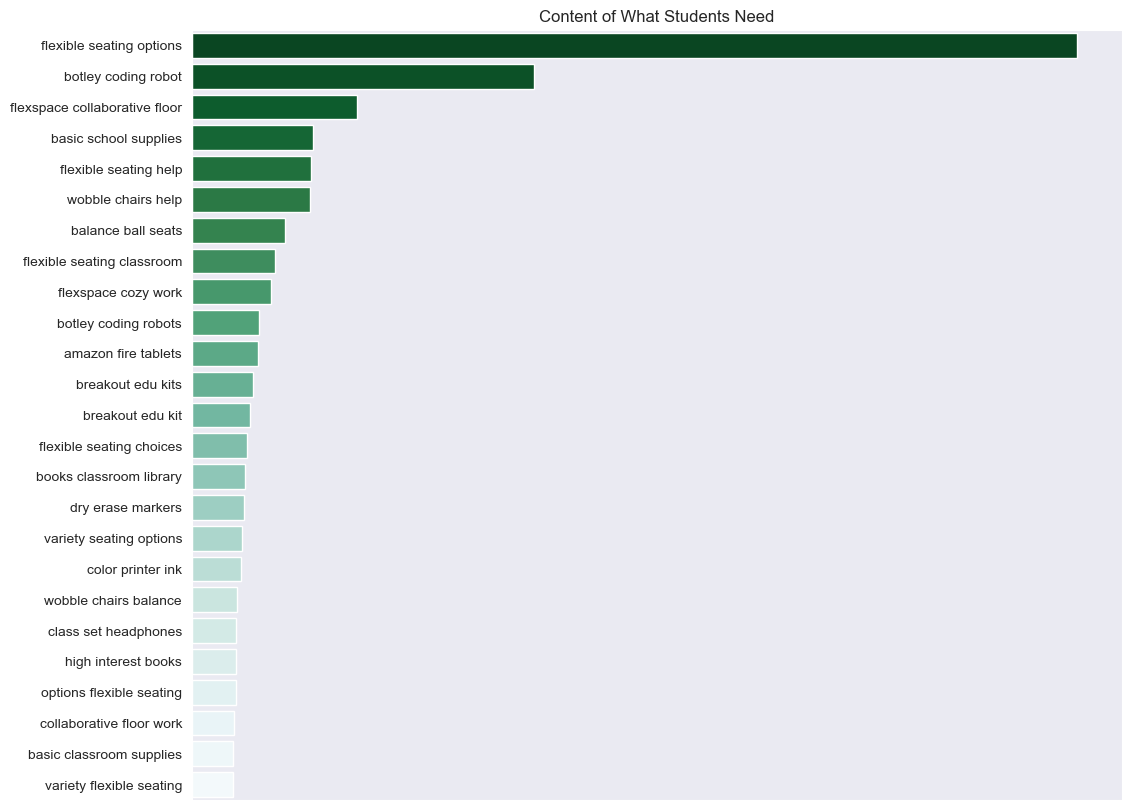

In [61]:
mystudents = []
for x in april18_df['clean_need']:
    if x.lower().strip().startswith("need"):
        phrase = " ".join(x.lower().strip().replace('need', '').split(". ")[0].split("!")[0].strip().split()[:3])
        mystudents.append(phrase)

t3 = Counter(mystudents).most_common(25)
x = [a[0] for a in t3]
y = [a[1] for a in t3]

sns.set_style("dark")
plt.figure(figsize = (12,10))
plt.title("Content of What Students Need")
bar = sns.barplot(y=x, x=y, palette="BuGn_r", edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Top Keywords");

> - Además de la necesidad principal sugerida por los maestros, es decir, <b>"Flexible seating options"</b>, otras necesidades frecuentes son <b>"Coding Robot"</b> y <b>"Basic School Supplies"</b>. En flexible seating se enfocan principalmente en <b>"Wobble Chairs and Balance Ball Seats"</b>. Otras necesidades relacionadas con tecnología incluyen <b>"Amazon Fire Tablets"</b>, <b>"Headphones Set"</b> y <b>"Osmo Genius Kit"</b>.

## <a href="8.2.5">8.2.5 Título del proyecto: palabras principales utilizadas</a>


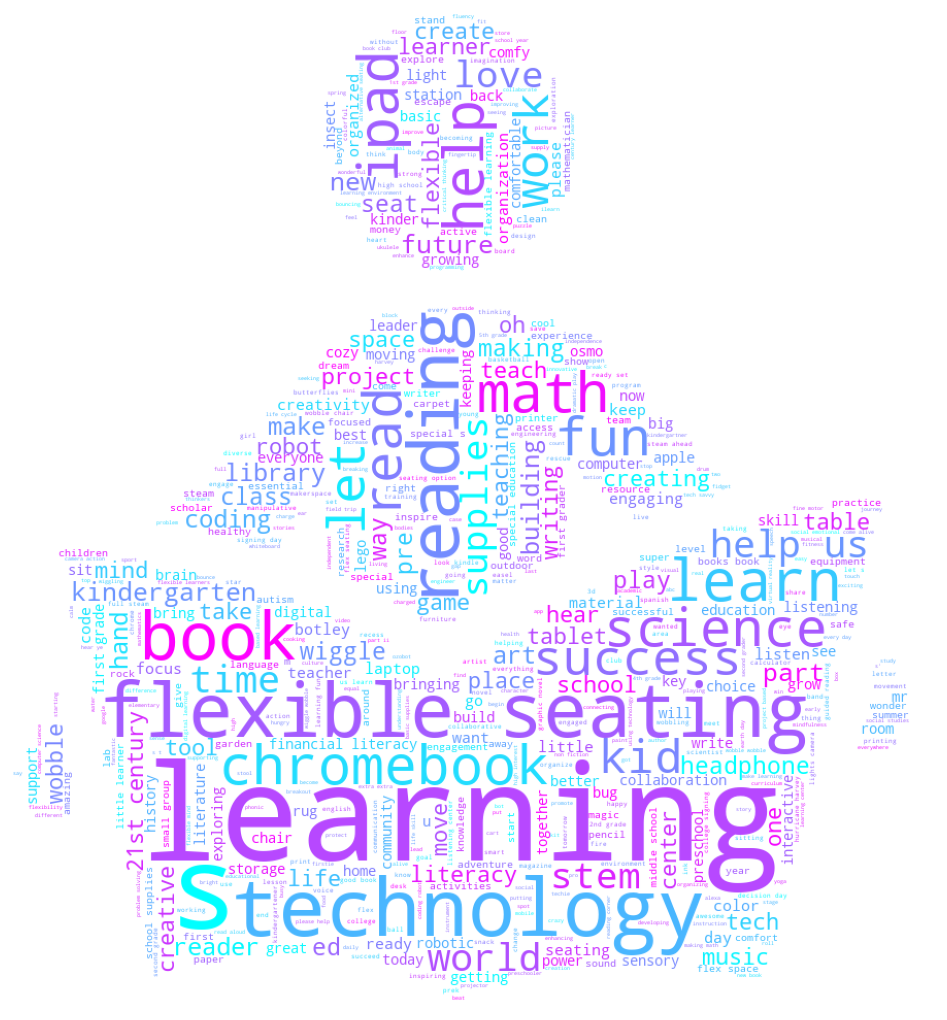

In [74]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Cargar la máscara de nube
mask = np.array(Image.open('cloud1.png'))

text = " ".join(
    april18_df['Project Title']
    .dropna()
    .astype(str)
).lower()

for w in ['need', 'student', 'classroom']:
    text = text.replace(w, " ")

wc = WordCloud(
    max_words=1200,
    stopwords=STOPWORDS,
    colormap='cool',
    background_color='white',
    mask=mask
).generate(text)

plt.figure(figsize=(13, 13))
plt.imshow(wc)
plt.axis('off')
plt.title('')
plt.show()

Temas como Flexible Seating, Chromebook, Reading, Learning, Technology y books son el enfoque principal de una gran cantidad de maestros para sus estudiantes.


## <a href="9">9. Comprensión y comparación de características clave de los proyectos</a>

## <a href="9.1">9.1 Proyectos expirados vs proyectos financiados</a> 

En esta sección se exploran y comprenden las características clave de los proyectos que fueron financiados exitosamente y se comparan con los proyectos que expiraron. El enfoque se centra en los proyectos del año anterior, es decir, 2017.


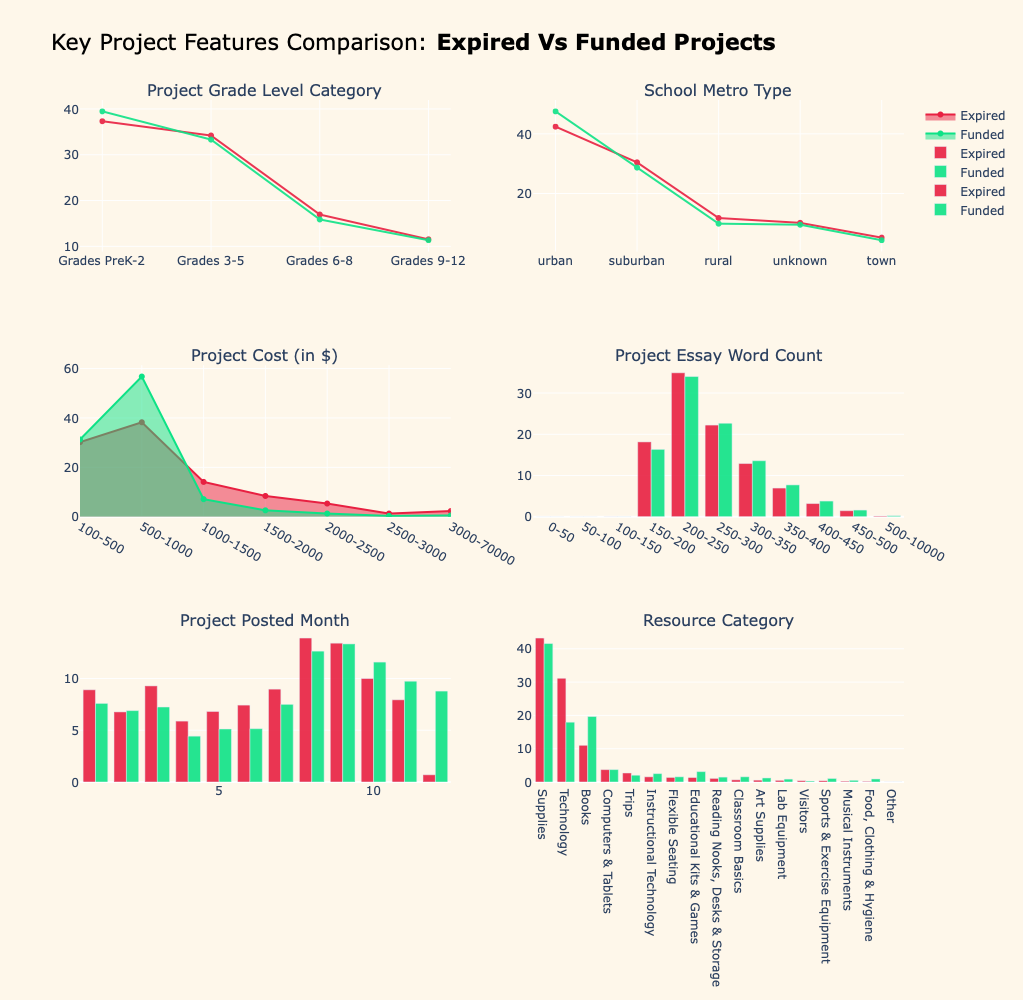

In [67]:
expired = projects_df[projects_df['Posted Year'] == 2017][projects_df['Project Current Status'] == 'Expired']
funded = projects_df[projects_df['Posted Year'] == 2017][projects_df['Project Current Status'] == 'Fully Funded']

expired = expired.merge(teachers_df, on="Teacher ID")
funded = funded.merge(teachers_df, on="Teacher ID")


def get_trace(col, func, flag=None,leg=False):

    t1 = expired[col].value_counts()
    t2 = funded[col].value_counts()

    if flag == 'num':
        t1 = expired[expired['NumProjects'] <= 20][col].value_counts()    
        t2 = funded[funded['NumProjects'] <= 20][col].value_counts() 
    
    trace1 = func(
        x=t1.index,
        y=[float(a)*100/sum(t1.values) for a in t1.values],
        name='Expired',
        marker=dict(color='#e82041'),
        showlegend=leg,
        opacity=0.9
    )
    trace2 = func(
        x=t2.index,
        y=[float(a)*100/sum(t2.values) for a in t2.values],
        name='Funded',
        marker=dict(color='#0de286'),
        opacity=0.9, showlegend=leg
    )
    
#     trace2 = func(x=t2.index, 
#                   y= [], 
#                   name='Funded', 
#                   marker=(), 
#                   opacity=0.5)
    return trace1, trace2

tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


########################
expired['wc'] = expired['Project Essay'].apply(lambda x : len(x.split()))
funded['wc'] = funded['Project Essay'].apply(lambda x : len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

expired['wc'] = pd.cut(expired['wc'], bins)
t1 = dict(expired['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Expired',
    marker=dict(color='#e82041'),
    opacity=0.9
)


funded['wc'] = pd.cut(funded['wc'], bins)
t2 = dict(funded['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Funded',
    marker=dict(color='#0de286'),
    opacity=0.9
)



############### cost ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

expired['binnedcost'] = pd.cut(expired['cost'], bins)
t1 = dict(expired['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-70000']
values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Expired',fill='tozeroy',
    marker=dict(color='#e82041'),
    opacity=0.9
)


funded['binnedcost'] = pd.cut(funded['cost'], bins)
t2 = dict(funded['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Funded',fill='tozeroy',
    marker=dict(color='#0de286'),
    opacity=0.9)



#############


titles = ['Project Grade Level Category', "School Metro Type","Project Cost (in $)", 
          "Project Essay Word Count", "Project Posted Month", "Resource Category"]
fig = tools.make_subplots(rows=3, cols=2, subplot_titles=titles, print_grid=False, specs=[[{}, {}],
                                                                  [{},{}], 
                                                                  [{}, {}],]) 
#                                                                   [{'colspan':2}, None],
#                                                                   [{}, None]
fig.append_trace(tr1, 1,1)
fig.append_trace(tr2, 1,1)
fig.append_trace(tr3, 1,2)
fig.append_trace(tr4, 1,2)
fig.append_trace(tr15, 2,1)
fig.append_trace(tr16, 2,1)
fig.append_trace(tr13, 2,2)
fig.append_trace(tr14, 2,2)
fig.append_trace(tr7, 3,2)
fig.append_trace(tr8, 3,2)
fig.append_trace(tr9, 3,1)
fig.append_trace(tr10, 3,1)

fig['layout'].update(

    barmode='group',

    title=dict(

        text='Key Project Features Comparison: <b>Expired Vs Funded Projects</b><br>',

        font=dict(

            size=22,

            color='#000'

        )

    ),

    margin=dict(t=100, b=100),

    paper_bgcolor='rgb(254, 247, 234)',

    plot_bgcolor='rgb(254, 247, 234)',

    height=1000

)

iplot(fig)

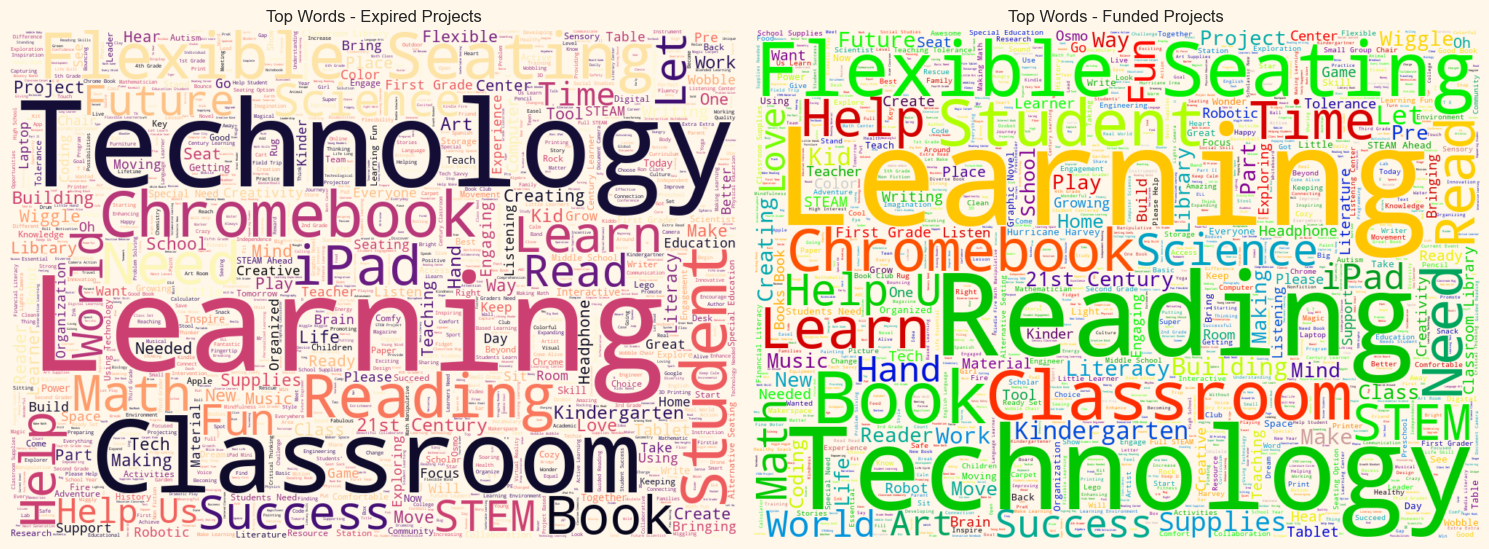

In [68]:
import random
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Si expired/funded están vacíos, volver a obtenerlos desde projects_df
if expired.empty:
    expired = projects_df[
        projects_df['Project Current Status'] == 'Expired'
    ].copy()

if funded.empty:
    funded = projects_df[
        projects_df['Project Current Status'] == 'Fully Funded'
    ].copy()

# Tomar títulos válidos
neg_text_cln = " ".join(
    expired['Project Title']
    .dropna()
    .astype(str)
    .tolist()
)

pos_text_cln = " ".join(
    funded['Project Title']
    .dropna()
    .astype(str)
    .tolist()
)

# Si aun así no hay títulos, usar Project Essay
if not neg_text_cln.strip() and 'Project Essay' in expired.columns:
    neg_text_cln = " ".join(
        expired['Project Essay']
        .dropna()
        .astype(str)
        .tolist()
    )

if not pos_text_cln.strip() and 'Project Essay' in funded.columns:
    pos_text_cln = " ".join(
        funded['Project Essay']
        .dropna()
        .astype(str)
        .tolist()
    )

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 8),
    facecolor='#fef7ea'
)

# Expired
if neg_text_cln.strip():
    wordcloud1 = WordCloud(
        max_words=1200,
        stopwords=STOPWORDS,
        colormap='magma',
        background_color='#fef7ea',
        width=1000,
        height=700
    ).generate(neg_text_cln)

    ax1.imshow(wordcloud1, interpolation='bilinear')
    ax1.set_title('Top Words - Expired Projects')
else:
    ax1.text(
        0.5, 0.5,
        'No hay texto disponible\nen proyectos expirados',
        ha='center',
        va='center',
        fontsize=14
    )
    ax1.set_title('Top Words - Expired Projects')

ax1.axis('off')

# Funded
if pos_text_cln.strip():
    wordcloud2 = WordCloud(
        max_words=1200,
        stopwords=STOPWORDS,
        colormap='nipy_spectral',
        background_color='#fef7ea',
        width=1000,
        height=700
    ).generate(pos_text_cln)

    ax2.imshow(wordcloud2, interpolation='bilinear')
    ax2.set_title('Top Words - Funded Projects')
else:
    ax2.text(
        0.5, 0.5,
        'No hay texto disponible\nen proyectos financiados',
        ha='center',
        va='center',
        fontsize=14
    )
    ax2.set_title('Top Words - Funded Projects')

ax2.axis('off')

plt.tight_layout()
plt.show()

> La comparación muestra las siguientes observaciones:
> - Los proyectos que pertenecen a **Grades PreK-2 Grade Level** tienen un mayor porcentaje de proyectos exitosos que expirados. En cambio, en los demás grados se observa un mayor porcentaje de proyectos expirados que financiados exitosamente. Tal vez los donadores prefieren **donar a niños de grados más bajos** que a grados más altos.
> - Los proyectos financiados exitosamente tienen un mayor porcentaje de escuelas ubicadas en **áreas urbanas**, mientras que los proyectos expirados tienen un mayor porcentaje de escuelas ubicadas en **áreas rurales, suburbanas o pueblos**.
> - Otra característica de los proyectos financiados se relaciona con el costo del proyecto. Los proyectos cuyo costo total es menor a USD 500 tienen un porcentaje muy alto de financiamiento exitoso; de forma inversa, un alto porcentaje de proyectos que expiraron tienen costos mayores a USD 500.
> - Los ensayos de proyecto son una parte esencial de los proyectos de DonorsChoose, y el número de palabras usadas en el texto tiene un papel importante en el resultado del proyecto. Como se observa en la cuarta gráfica, los proyectos financiados exitosamente son más comunes cuando el **ensayo tiene más de 250 palabras**. Esto indica que se debería motivar a los maestros a escribir de manera más completa sobre sus proyectos.
> - Una cantidad significativa de proyectos publicados en el cuarto trimestre del año, es decir, entre **octubre y diciembre**, fueron financiados exitosamente. Esto indica un buen periodo en el que los donadores tienden a donar más. Tal vez los maestros que sienten que no están recibiendo donaciones en sus proyectos podrían comenzar a publicarlos en noviembre o diciembre. En los demás meses del año se observa un mayor porcentaje de proyectos expirados que financiados.
> - Una observación interesante entre los proyectos expirados es que una gran proporción tenía costos altos relacionados con recursos tecnológicos como **iPads, Chromebooks**, etc. Las categorías de recursos **supplies y technologies** tienen una presencia muy alta en los proyectos expirados.


In [69]:
# Comparación: proyectos con tiempo de financiamiento corto vs largo

projects_df = projects_df.copy()

# Convertir Funding Time a número de días
projects_df['time'] = (
    projects_df['Funding Time']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

projects_df['time'] = pd.to_numeric(
    projects_df['time'],
    errors='coerce'
)

tempdf = projects_df.dropna(subset=['time']).copy()
tempdf = tempdf[tempdf['Posted Year'] == 2017].copy()

# Tiempo corto: 1 día o menos
df1 = tempdf[tempdf['time'] <= 1].copy()

# Tiempo largo: 60 días o más
df2 = tempdf[tempdf['time'] >= 60].copy()

# Agregar datos de maestros
df1 = df1.merge(teachers_df, on='Teacher ID', how='left')
df2 = df2.merge(teachers_df, on='Teacher ID', how='left')


def get_trace(col, func, flag=None, leg=False):
    t1 = df1[col].value_counts()
    t2 = df2[col].value_counts()

    if flag == 'num':
        t1 = df1[df1['NumProjects'] <= 20][col].value_counts()
        t2 = df2[df2['NumProjects'] <= 20][col].value_counts()

    total1 = t1.sum()
    total2 = t2.sum()

    trace1 = func(
        x=t1.index.tolist(),
        y=[float(a) * 100 / total1 for a in t1.values] if total1 > 0 else [],
        name='Small Funding Duration',
        marker=dict(color='#0de286'),
        showlegend=leg,
        opacity=0.9
    )

    trace2 = func(
        x=t2.index.tolist(),
        y=[float(a) * 100 / total2 for a in t2.values] if total2 > 0 else [],
        name='Large Funding Duration',
        marker=dict(color='#e82041'),
        opacity=0.9,
        showlegend=leg
    )

    return trace1, trace2


tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


# Función para obtener porcentajes por rangos
def porcentajes_por_rango(serie, bins, order):
    categorias = pd.cut(serie, bins=bins)

    conteos = categorias.value_counts().sort_index()
    total = conteos.sum()

    resultado = {}

    for intervalo, cantidad in conteos.items():
        etiqueta = (
            str(intervalo)
            .replace(']', '')
            .replace('(', '')
            .replace(', ', '-')
        )
        resultado[etiqueta] = (cantidad * 100 / total) if total > 0 else 0

    return [resultado.get(valor, 0) for valor in order]


# Palabras por ensayo
df1['wc'] = (
    df1['Project Essay']
    .fillna('')
    .astype(str)
    .apply(lambda x: len(x.split()))
)

df2['wc'] = (
    df2['Project Essay']
    .fillna('')
    .astype(str)
    .apply(lambda x: len(x.split()))
)

bins_wc = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

order_wc = [
    '0-50', '50-100', '100-150', '150-200', '200-250',
    '250-300', '300-350', '350-400', '400-450',
    '450-500', '500-10000'
]

values_df1_wc = porcentajes_por_rango(
    df1['wc'],
    bins_wc,
    order_wc
)

values_df2_wc = porcentajes_por_rango(
    df2['wc'],
    bins_wc,
    order_wc
)

tr13 = go.Bar(
    x=order_wc,
    y=values_df1_wc,
    name='Small Funding Duration',
    marker=dict(color='#0de286'),
    showlegend=False,
    opacity=0.9
)

tr14 = go.Bar(
    x=order_wc,
    y=values_df2_wc,
    name='Large Funding Duration',
    marker=dict(color='#e82041'),
    showlegend=False,
    opacity=0.9
)


# Costo de proyectos
bins_cost = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

order_cost = [
    '100-500', '500-1000', '1000-1500', '1500-2000',
    '2000-2500', '2500-3000', '3000-70000'
]

values_df1_cost = porcentajes_por_rango(
    df1['cost'],
    bins_cost,
    order_cost
)

values_df2_cost = porcentajes_por_rango(
    df2['cost'],
    bins_cost,
    order_cost
)

tr15 = go.Scatter(
    x=order_cost,
    y=values_df1_cost,
    name='Small Funding Time',
    fill='tozeroy',
    marker=dict(color='#0de286'),
    showlegend=False,
    opacity=0.9
)

tr16 = go.Scatter(
    x=order_cost,
    y=values_df2_cost,
    name='Large Funding Time',
    fill='tozeroy',
    marker=dict(color='#e82041'),
    showlegend=False,
    opacity=0.9
)


titles = [
    'Project Grade Level Category',
    'School Metro Type',
    'Project Cost (in $)',
    'Project Essay Word Count',
    'Project Posted Month',
    'Resource Category'
]

fig = tools.make_subplots(
    rows=3,
    cols=2,
    subplot_titles=titles,
    print_grid=False,
    specs=[
        [{}, {}],
        [{}, {}],
        [{}, {}]
    ]
)

fig.append_trace(tr1, 1, 1)
fig.append_trace(tr2, 1, 1)

fig.append_trace(tr3, 1, 2)
fig.append_trace(tr4, 1, 2)

fig.append_trace(tr15, 2, 1)
fig.append_trace(tr16, 2, 1)

fig.append_trace(tr13, 2, 2)
fig.append_trace(tr14, 2, 2)

fig.append_trace(tr7, 3, 2)
fig.append_trace(tr8, 3, 2)

fig.append_trace(tr9, 3, 1)
fig.append_trace(tr10, 3, 1)

fig['layout'].update(
    barmode='group',

    title=dict(
        text='Key Project Features Comparison: <b>Projects with Small Vs Larger Funding Time</b><br>',
        font=dict(
            size=22,
            color='#000'
        )
    ),

    legend=dict(
        x=0.25,
        y=1.06,
        orientation='h'
    ),

    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000
)

iplot(fig)

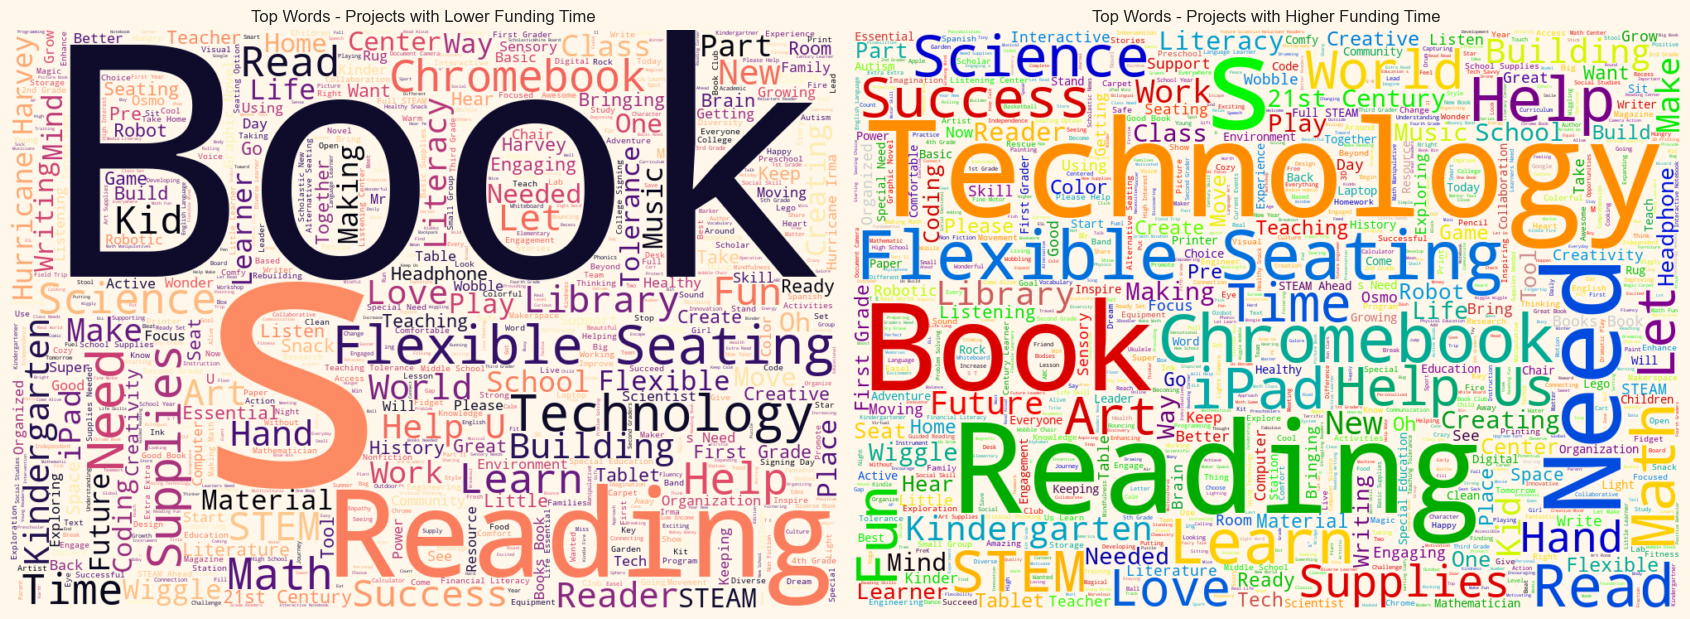

In [70]:
import random
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Unir títulos válidos
pos_text_cln = " ".join(
    df2['Project Title']
    .dropna()
    .astype(str)
    .tolist()
)

neg_text_cln = " ".join(
    df1['Project Title']
    .dropna()
    .astype(str)
    .tolist()
)

# Quitar palabras repetidas o poco útiles
noise = ['learning', 'student', 'students', 'classroom', 'project']

for n in noise:
    pos_text_cln = pos_text_cln.replace(n, " ")
    pos_text_cln = pos_text_cln.replace(n.title(), " ")

    neg_text_cln = neg_text_cln.replace(n, " ")
    neg_text_cln = neg_text_cln.replace(n.title(), " ")

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(17, 8),
    facecolor='#fef7ea'
)

# Proyectos con menor tiempo de financiamiento
if neg_text_cln.strip():
    wordcloud1 = WordCloud(
        max_words=1200,
        stopwords=STOPWORDS,
        colormap='magma',
        background_color='#fef7ea',
        width=1000,
        height=700
    ).generate(neg_text_cln)

    ax1.imshow(wordcloud1, interpolation='bilinear')
else:
    ax1.text(
        0.5, 0.5,
        'No hay títulos disponibles',
        ha='center',
        va='center',
        fontsize=14
    )

ax1.axis('off')
ax1.set_title('Top Words - Projects with Lower Funding Time')

# Proyectos con mayor tiempo de financiamiento
if pos_text_cln.strip():
    wordcloud2 = WordCloud(
        max_words=1200,
        stopwords=STOPWORDS,
        colormap='nipy_spectral',
        background_color='#fef7ea',
        width=1000,
        height=700
    ).generate(pos_text_cln)

    ax2.imshow(wordcloud2, interpolation='bilinear')
else:
    ax2.text(
        0.5, 0.5,
        'No hay títulos disponibles',
        ha='center',
        va='center',
        fontsize=14
    )

ax2.axis('off')
ax2.set_title('Top Words - Projects with Higher Funding Time')

plt.tight_layout()
plt.show()

> La comparación muestra las siguientes observaciones:
> - Se puede observar que los proyectos que fueron financiados exitosamente en un día o menos pertenecen con mayor frecuencia a **Grades 6-12 Grade Levels**, mientras que un mayor porcentaje de proyectos que tardaron más tiempo en completar las donaciones pertenece a grados más bajos.
> - Las **áreas suburbanas** tuvieron un mayor porcentaje de proyectos completados en periodos de tiempo más cortos en comparación con cualquier otro tipo de zona escolar.
> - Se espera que los proyectos con menor costo total, es decir, menores a USD 500, tengan mayores probabilidades de cerrarse o financiarse en muy poco tiempo, en comparación con proyectos que requieren montos más altos. Esto mismo se observa en las gráficas.
> - En los proyectos financiados en menos de un día, los maestros utilizaron relativamente **más palabras** en sus ensayos, es decir, más de 250. Para proyectos con ensayos de menos de 500 palabras, se observaron más proyectos financiados en periodos de tiempo más largos.
> - Una mayor cantidad de proyectos publicados en los meses de **febrero, marzo, agosto y octubre** fueron financiados exitosamente en un periodo de tiempo más corto, mientras que el mayor porcentaje de proyectos financiados en más tiempo se observó en los meses de diciembre y septiembre.

## <a href="9.3">9.3 Proyectos con un solo donador vs múltiples donadores</a> 

Se comparan las características de los proyectos en los que donó un solo donador frente a aquellos en los que donaron más de diez donadores.


In [71]:
num_donations = donations_df.groupby('Project ID').agg({
    'Donation ID': 'count'
}).reset_index().rename(columns={
    'Donation ID': 'NumDonations'
})

tempdf = projects_df.merge(num_donations, on="Project ID")

df1 = tempdf[
    (tempdf['Posted Year'] == 2017) &
    (tempdf['NumDonations'] == 1)
]

df2 = tempdf[
    (tempdf['Posted Year'] == 2017) &
    (tempdf['NumDonations'] > 10)
]

df1 = df1.merge(teachers_df, on="Teacher ID")
df2 = df2.merge(teachers_df, on="Teacher ID")


def get_trace(col, func, flag=None, leg=False):

    t1 = df1[col].value_counts()
    t2 = df2[col].value_counts()

    if flag == 'num':
        t1 = df1[df1['NumProjects'] <= 20][col].value_counts()
        t2 = df2[df2['NumProjects'] <= 20][col].value_counts()

    trace1 = func(
        x=t1.index,
        y=[float(a) * 100 / sum(t1.values) for a in t1.values],
        name='Single Donors',
        marker=dict(color='#0de286'),
        showlegend=leg,
        opacity=0.9
    )

    trace2 = func(
        x=t2.index,
        y=[float(a) * 100 / sum(t2.values) for a in t2.values],
        name='Multiple Donors',
        marker=dict(color='#e82041'),
        opacity=0.9,
        showlegend=leg
    )

    return trace1, trace2


tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


# Project Essay Word Count

df1['wc'] = df1['Project Essay'].apply(lambda x: len(x.split()))
df2['wc'] = df2['Project Essay'].apply(lambda x: len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

df1['wc'] = pd.cut(df1['wc'], bins)

t1 = dict(df1['wc'].value_counts())

labels = [
    str(b).replace("]", "").replace("(", "").replace(", ", "-")
    for b in t1.keys()
]

vals = [
    float(a) * 100 / sum(t1.values())
    for a in list(t1.values())
]

d = {}

for i, v in enumerate(labels):
    d[v] = vals[i]

order = [
    '0-50', '50-100', '100-150', '150-200', '200-250',
    '250-300', '300-350', '350-400', '400-450',
    '450-500', '500-10000'
]

values = [d.get(v, 0) for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Single Donors',
    marker=dict(color='#0de286'),
    showlegend=False,
    opacity=0.9
)


df2['wc'] = pd.cut(df2['wc'], bins)

t2 = dict(df2['wc'].value_counts())

labels = [
    str(b).replace("]", "").replace("(", "").replace(", ", "-")
    for b in t2.keys()
]

vals = [
    float(a) * 100 / sum(t2.values())
    for a in list(t2.values())
]

d = {}

for i, v in enumerate(labels):
    d[v] = vals[i]

values = [d.get(v, 0) for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Multiple Donors',
    marker=dict(color='#e82041'),
    showlegend=False,
    opacity=0.9
)


# Project Cost

bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

df1['binnedcost'] = pd.cut(df1['cost'], bins)

t1 = dict(df1['binnedcost'].value_counts())

labels = [
    str(b).replace("]", "").replace("(", "").replace(", ", "-")
    for b in t1.keys()
]

vals = [
    float(a) * 100 / sum(t1.values())
    for a in list(t1.values())
]

d = {}

for i, v in enumerate(labels):
    d[v] = vals[i]

order = [
    '100-500', '500-1000', '1000-1500', '1500-2000',
    '2000-2500', '2500-3000', '3000-70000'
]

values = [d.get(v, 0) for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Single Donors',
    fill='tozeroy',
    marker=dict(color='#0de286'),
    showlegend=False,
    opacity=0.9
)


df2['binnedcost'] = pd.cut(df2['cost'], bins)

t2 = dict(df2['binnedcost'].value_counts())

labels = [
    str(b).replace("]", "").replace("(", "").replace(", ", "-")
    for b in t2.keys()
]

vals = [
    float(a) * 100 / sum(t2.values())
    for a in list(t2.values())
]

d = {}

for i, v in enumerate(labels):
    d[v] = vals[i]

values = [d.get(v, 0) for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Multiple Donors',
    fill='tozeroy',
    marker=dict(color='#e82041'),
    showlegend=False,
    opacity=0.9
)


titles = [
    'Project Grade Level Category',
    'School Metro Type',
    'Project Cost (in $)',
    'Project Essay Word Count',
    'Project Posted Month',
    'Resource Category'
]

fig = tools.make_subplots(
    rows=3,
    cols=2,
    subplot_titles=titles,
    print_grid=False,
    specs=[
        [{}, {}],
        [{}, {}],
        [{}, {}]
    ]
)

fig.append_trace(tr1, 1, 1)
fig.append_trace(tr2, 1, 1)

fig.append_trace(tr3, 1, 2)
fig.append_trace(tr4, 1, 2)

fig.append_trace(tr15, 2, 1)
fig.append_trace(tr16, 2, 1)

fig.append_trace(tr13, 2, 2)
fig.append_trace(tr14, 2, 2)

fig.append_trace(tr7, 3, 2)
fig.append_trace(tr8, 3, 2)

fig.append_trace(tr9, 3, 1)
fig.append_trace(tr10, 3, 1)

fig['layout'].update(
    barmode='group',

    title=dict(
        text='Key Project Features Comparison: <b>Projects with Single Vs Multiple Donors</b><br>',
        font=dict(
            size=22,
            color='#000'
        )
    ),

    legend=dict(
        x=0.25,
        y=1.06,
        orientation="h"
    ),

    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000
)

iplot(fig)

In [72]:
print("Projects:", projects_df.shape)
print("Donations:", donations_df.shape)

print("\nEjemplos Project ID en Projects:")
print(projects_df['Project ID'].head())

print("\nEjemplos Project ID en Donations:")
print(donations_df['Project ID'].head())

print("\nCoincidencias:")
print(
    projects_df['Project ID']
    .astype(str)
    .isin(donations_df['Project ID'].astype(str))
    .sum()
)

Projects: (1110003, 39)
Donations: (4687884, 13)

Ejemplos Project ID en Projects:
0    7685f0265a19d7b52a470ee4bac883ba
1    f9f4af7099061fb4bf44642a03e5c331
2    afd99a01739ad5557b51b1ba0174e832
3    c614a38bb1a5e68e2ae6ad9d94bb2492
4    ec82a697fab916c0db0cdad746338df9
Name: Project ID, dtype: object

Ejemplos Project ID en Donations:
0    000009891526c0ade7180f8423792063
1    000009891526c0ade7180f8423792063
2    000009891526c0ade7180f8423792063
3    000009891526c0ade7180f8423792063
4    000009891526c0ade7180f8423792063
Name: Project ID, dtype: object

Coincidencias:
873838


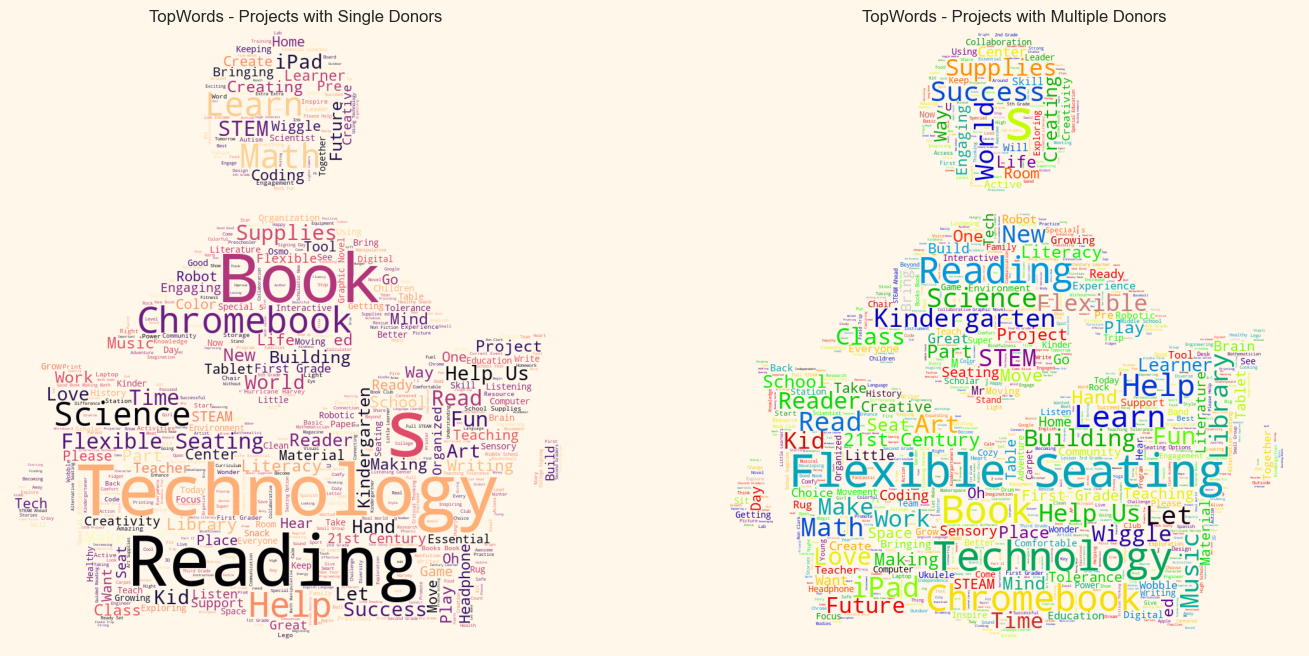

In [73]:
pos_text_cln = " ".join(df2['Project Title'])
neg_text_cln = " ".join(df1['Project Title'])

noise = ['Learning', 'Student', 'Classroom', 'Need']
for n in noise:
    pos_text_cln = pos_text_cln.replace(n," ")
    neg_text_cln = neg_text_cln.replace(n," ")
    
def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(85, 140), random.randint(60, 80))

def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(0, 35), random.randint(60, 80))
    
from PIL import Image
mask = np.array(Image.open('cloud1.png'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[17, 8], facecolor='#fef7ea')

wordcloud1 = WordCloud(max_words=1200,colormap='magma',
                       background_color='rgb(254, 247, 234)',mask=mask).generate(neg_text_cln)
ax1.imshow(wordcloud1)
ax1.axis('off');
ax1.set_title('TopWords - Projects with Single Donors');

wordcloud2 = WordCloud(max_words=1200,colormap='nipy_spectral', background_color='rgb(254, 247, 234)', mask=mask
                      ).generate(pos_text_cln)
ax2.imshow(wordcloud2)
ax2.axis('off');
ax2.set_title('TopWords - Projects with Multiple Donors');

> - Con base en las gráficas y comparaciones anteriores, se pueden observar los siguientes puntos:<br><br>

> - Un mayor porcentaje de proyectos en los que donó un solo donador presentó las siguientes características:
> - Pertenecían a **PreK-2**, fueron publicados por escuelas en **áreas urbanas**, tenían costos de proyecto menores, los maestros usaron ensayos con **pocas palabras**, es decir, menos de 250, fueron publicados en los meses de **septiembre, octubre y diciembre**, y trataban principalmente sobre **libros**.
> - Un mayor porcentaje de proyectos en los que donaron múltiples donadores presentó las siguientes características:
> - Pertenecían a grados más altos, es decir, **Grade level 3 - 12**, fueron publicados por escuelas en **áreas suburbanas y rurales**, tenían un costo de proyecto **mayor a USD 500**, usaban una mayor cantidad de palabras en los ensayos y se relacionaban con **tecnologías y suministros**.


## FINAL ##

AL FARIAS LEYVA
230389
